# Time Series Sales Forecasting
Multi-Model Evaluation: SARIMA, XGBoost, LSTM & Hybrid Approaches

## Project Objective

Accurate demand forecasting is essential for inventory optimisation, financial planning, and risk management. This project develops and evaluates multiple forecasting approaches to predict book sales using historical time series data. The objective is to compare classical statistical models, machine learning methods, deep learning architectures, and hybrid techniques to determine which strategy performs best under different demand behaviours.

## Approaches Used

To evaluate forecasting performance across different demand behaviours, multiple modelling approaches were implemented:

1. **Classical Statistical Modelling (SARIMA)**  
   To capture linear trend and seasonal structure in weekly sales data.

2. **Machine Learning (XGBoost)**  
   To evaluate whether nonlinear relationships and lag-based feature engineering improve predictive performance.

3. **Deep Learning (LSTM)**  
   To model complex temporal dependencies and nonlinear demand patterns.

4. **Hybrid Models**
   - Sequential Hybrid (SARIMA + LSTM on residuals)
   - Parallel Hybrid (Weighted combination)

5. **Temporal Aggregation Comparison**
   Weekly vs Monthly forecasting performance.

This structured comparison enables evaluation of model effectiveness under varying demand characteristics and planning horizons.

# Import packages and data

In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 18.3 MB/s eta 0:00:00


In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.7 MB/s eta 0:00:00


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler

from pmdarima import auto_arima
from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow import keras
from keras import layers
import keras_tuner as kt

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Load Data 1

In [ ]:
# Load the dataset 1 from Excel (all four tabs)
file_path1 = "/content/ISBN List.xlsx"

# Read all sheets into a dictionary
all_sheets1 = pd.read_excel(file_path1, sheet_name=None)

# Check sheet names
print(all_sheets1.keys())

dict_keys(['F - Adult Fiction', 'S Adult Non-Fiction Specialist', 'T Adult Non-Fiction Trade', "Y Children's, YA & Educational"])


In [ ]:
# Combine the data into a datframe
ISBN_df = pd.concat(all_sheets1.values(), ignore_index=True)

ISBN_df.head()

,ISBN,Title,Author,Imprint,Publisher Group,RRP,Binding,Publication Date,Product Class,Country of Publication
0,9780330375252,Bridget Jones's Diary (Film Tie-in),"Fielding, Helen",Picador,Pan Macmillan Grp,8.99,Paperback,2001-03-23,F1.1 General & Literary Fiction,United Kingdom
1,9780140276336,White Teeth,"Smith, Zadie",Penguin Books Ltd,Penguin Grp,9.99,Paperback,2001-01-25,F1.1 General & Literary Fiction,United Kingdom
2,9780006512134,Man and Boy,"Parsons, Tony",HarperCollins Publishers,HarperCollins Grp,8.99,Paperback,2000-03-06,F1.1 General & Literary Fiction,United Kingdom
3,9780099280255,"Brethren,The","Grisham, John",Arrow Books,Random House Grp,6.99,Paperback,2000-12-27,"F2.1 Crime, Thriller & Adventure",United Kingdom
4,9780552998727,Marrying The Mistress:an irresistible and grip...,"Trollope, Joanna",Black Swan,Transworld Grp,10.99,Paperback,2001-02-01,F1.1 General & Literary Fiction,United Kingdom


## Load Data 2

In [ ]:
# Load the dataset 2 from Excel (all four tabs)
file_path2 = "/content/UK Weekly Trended Timeline from 200101_202429.xlsx"

# Read all sheets into a dictionary
all_sheets2 = pd.read_excel(file_path2, sheet_name=None)

# Check sheet names
print(all_sheets2.keys())

dict_keys(['F Adult Fiction', 'S Adult Non-Fiction Specialist', 'T Adult Non-Fiction Trade', "Y Children's, YA & Educational"])


In [ ]:
# Combine the data into a datframe
UK_Trend_df = pd.concat(all_sheets2.values(), ignore_index=True)

UK_Trend_df.head()

,ISBN,Title,Author,Interval,End Date,Volume,Value,ASP,RRP,Binding,Imprint,Publisher Group,Product Class
0,9780002261821,One For My Baby,"Parsons, Tony",200513,2005-04-02,1,15.99,15.99,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction
1,9780002261821,One For My Baby,"Parsons, Tony",200503,2005-01-22,1,15.99,15.99,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction
2,9780002261821,One For My Baby,"Parsons, Tony",200422,2004-05-29,1,11.19,11.19,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction
3,9780002261821,One For My Baby,"Parsons, Tony",200415,2004-04-10,2,27.18,13.59,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction
4,9780002261821,One For My Baby,"Parsons, Tony",200404,2004-01-24,2,22.48,11.24,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction


# Conducting Initial Data Investigation

In [ ]:
print("ISBN Dataset: ", ISBN_df.shape)
print("Uk Weekly Trend Dataset: ", UK_Trend_df.shape)

ISBN Dataset:  (500, 10)
Uk Weekly Trend Dataset:  (227224, 13)


After combining the four tabs of data, the ISBN dataset contains 500 records and the Uk Weekly Trend dataset has 227224 records.

In [ ]:
ISBN_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ISBN                    500 non-null    int64         
 1   Title                   500 non-null    object        
 2   Author                  426 non-null    object        
 3   Imprint                 500 non-null    object        
 4   Publisher Group         500 non-null    object        
 5   RRP                     473 non-null    float64       
 6   Binding                 500 non-null    object        
 7   Publication Date        500 non-null    datetime64[ns]
 8   Product Class           500 non-null    object        
 9   Country of Publication  500 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(7)
memory usage: 39.2+ KB


In [ ]:
UK_Trend_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227224 entries, 0 to 227223
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   ISBN             227224 non-null  int64         
 1   Title            227224 non-null  object        
 2   Author           212345 non-null  object        
 3   Interval         227224 non-null  int64         
 4   End Date         227224 non-null  datetime64[ns]
 5   Volume           227224 non-null  int64         
 6   Value            227224 non-null  float64       
 7   ASP              226881 non-null  float64       
 8   RRP              221262 non-null  float64       
 9   Binding          227224 non-null  object        
 10  Imprint          227224 non-null  object        
 11  Publisher Group  227224 non-null  object        
 12  Product Class    227224 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(3), object(6)
memory usage: 22.5+ 

## Convert ISBN to string

In [ ]:
# Convert ISBN to string
UK_Trend_df['ISBN'] = UK_Trend_df['ISBN'].astype(str)

## Convert date to DateTime and Set the index

In [ ]:

# Convert date to datetime
UK_Trend_df['End Date'] = pd.to_datetime(UK_Trend_df['End Date'])

# Set date as index
UK_Trend_df = UK_Trend_df.set_index('End Date')
UK_Trend_df = UK_Trend_df.sort_index()

UK_Trend_df

,ISBN,Title,Author,Interval,Volume,Value,ASP,RRP,Binding,Imprint,Publisher Group,Product Class
End Date,,,,,,,,,,,,
2001-01-06,9780416196764,Tigger's Little Book of Bounce,"Milne, A. A.",200101,765,1518.35,1.9848,2.50,Paperback,Methuen & Co.,Other Publisher Groups,Y1.1 Pre-school & Early Learning
2001-01-06,9780091816971,Who Moved My Cheese,"Johnson, Dr Spencer",200101,532,2994.68,5.6291,8.99,Paperback,Vermilion,Random House Grp,T17.1 Careers & Success
2001-01-06,9780201354935,"HTML 4 for the World Wide Web, Fourth Edition","Castro, Elizabeth",200101,185,2603.66,14.0738,14.99,Paperback,"Peachpit Press Publications,U.S.",Pearson Education: Prof Grp,S10.2 Computing: Professional & Programming
2001-01-06,9780850395846,"to Z of London Mini Street Atlas, A",NaN,200101,1199,4695.23,3.9160,3.95,Paperback,Geographers' A-Z Map Co.,Geographers A-Z Grp,T14.8 Street Maps & City Plans
2001-01-06,9780004724140,Collins Gem Spanish Dictionary,Harpercollins Publishers,200101,374,1481.47,3.9611,3.99,Paperback,CollinsGem,HarperCollins Grp,T2.3 Bilingual Dictionaries
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-20,9780340696767,Nathaniel's Nutmeg,"Milton, Giles",202429,12,130.60,10.8833,12.99,Paperback,Hodder & Stoughton Ltd,Hodder & Stoughton Grp,"T4.2 Biography: Historical, Political & Military"
2024-07-20,9780749397548,Captain Corelli's Mandolin,"de Bernières, Louis",202429,132,1239.35,9.3890,9.99,Paperback,Minerva,Random House Grp,F1.1 General & Literary Fiction
2024-07-20,9781841150437,Bad Blood,"Sage, Lorna",202429,1,10.99,10.9900,10.99,Paperback,Fourth Estate,HarperCollins Grp,T4.5A Autobiography: Literary


## Resample weekly per ISBN

In [ ]:
# Create empty list to store processed ISBN data

resampled_list = []

for isbn, group in UK_Trend_df.groupby('ISBN'):

    group = group.sort_index()

    weekly = group['Volume'].resample('W').sum().fillna(0)

    weekly_df = weekly.to_frame()
    weekly_df['ISBN'] = isbn

    weekly_df.index.name = 'End Date'

    resampled_list.append(weekly_df)

weekly_data = pd.concat(resampled_list)
weekly_data.head()

,Volume,ISBN
End Date,,
2001-01-07,522,9780001713031
2001-01-14,379,9780001713031
2001-01-21,393,9780001713031
2001-01-28,369,9780001713031
2001-02-04,423,9780001713031


### Check the resampling

In [ ]:
weekly_data.isna().sum()

,0
Volume,0
ISBN,0


In [ ]:
sample_isbn = weekly_data['ISBN'].iloc[0]

weekly_data[weekly_data['ISBN'] == sample_isbn].head(15)

,Volume,ISBN
End Date,,
2001-01-07,522,9780001713031
2001-01-14,379,9780001713031
2001-01-21,393,9780001713031
2001-01-28,369,9780001713031
2001-02-04,423,9780001713031
2001-02-11,435,9780001713031
2001-02-18,562,9780001713031
2001-02-25,843,9780001713031
2001-03-04,582,9780001713031


## Filter ISBNs with sales data beyond 2024-07-01

In [ ]:
cutoff_date = '2024-07-01'

ISBN_last_date = weekly_data.groupby('ISBN').apply(lambda x: x.index.max())

valid_ISBNs = ISBN_last_date[ISBN_last_date > cutoff_date].index

print(valid_ISBNs)


Index(['9780006512134', '9780006514091', '9780006514213', '9780006531203',
       '9780006550433', '9780006647553', '9780007101887', '9780091816971',
       '9780091867775', '9780099244721', '9780099285823', '9780099286387',
       '9780099286578', '9780099422587', '9780099428558', '9780099771517',
       '9780140259506', '9780140275421', '9780140276336', '9780140276619',
       '9780140281293', '9780140285215', '9780140294231', '9780140295962',
       '9780224060875', '9780241003008', '9780261103252', '9780330355667',
       '9780340696767', '9780340766057', '9780340786055', '9780349112763',
       '9780349113609', '9780349114033', '9780440864141', '9780440864554',
       '9780552145053', '9780552145060', '9780552145954', '9780552997034',
       '9780552997348', '9780552998000', '9780552998444', '9780552998482',
       '9780552998727', '9780593048153', '9780719559792', '9780722532935',
       '9780744523232', '9780747268161', '9780749395698', '9780749397548',
       '9780752844299', '

/tmp/ipython-input-262/1796572366.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ISBN_last_date = weekly_data.groupby('ISBN').apply(lambda x: x.index.max())


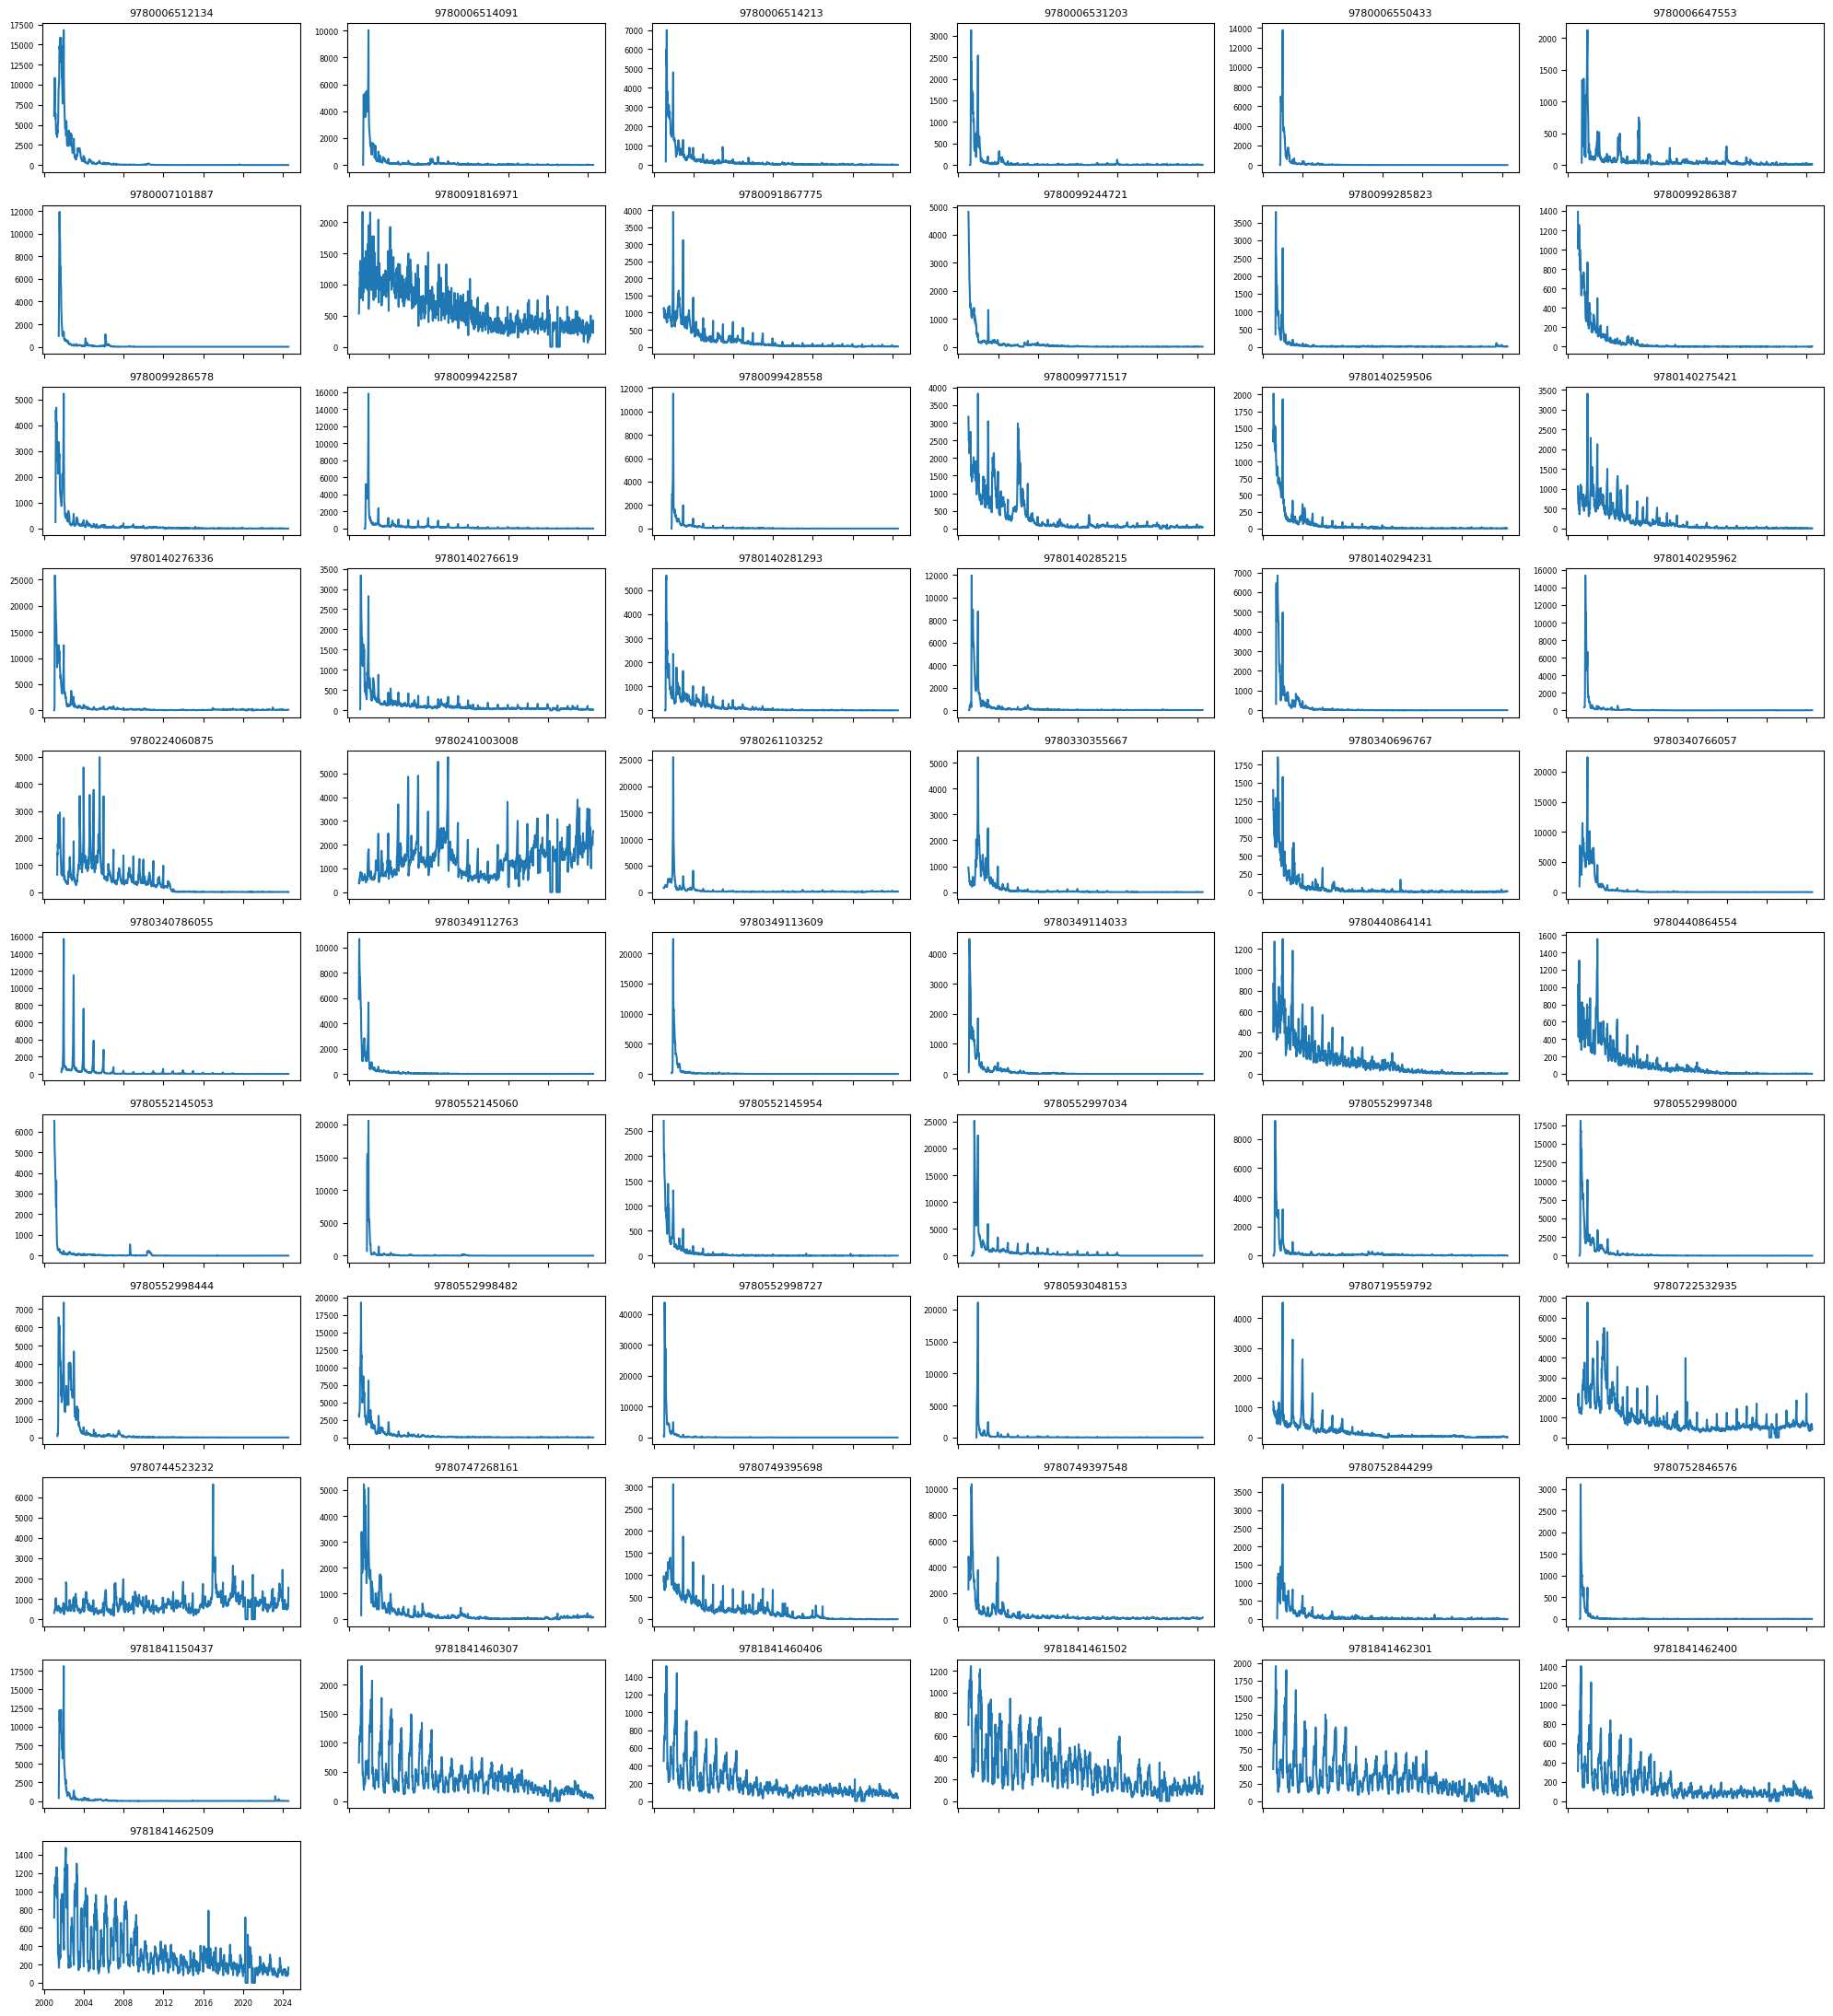

In [ ]:
filtered_data = weekly_data[weekly_data['ISBN'].isin(valid_ISBNs)]

isbns = list(valid_ISBNs)

n = len(isbns)
cols = 6
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 2), sharex=True)
axes = axes.flatten()

for i, isbn in enumerate(isbns):
    book_data = weekly_data[weekly_data['ISBN'] == isbn]

    axes[i].plot(book_data.index, book_data['Volume'])
    axes[i].set_title(isbn, fontsize=8)
    axes[i].tick_params(axis='both', labelsize=6)

# Remove empty plots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### **Pattern Observations**

After resampling and analysing sales data beyond July 2024 across 61 active titles, four recurring demand patterns were identified:

**1. Launch Spike with Gradual Decline**

Many titles show a strong sales surge at launch followed by a steady decline. This reflects initial marketing impact and early consumer interest, with demand stabilising at lower levels over time. These titles generate strong short-term revenue but require cautious long-term inventory planning.

**2. Initial Peak with Long Stable Tail**

Some books experience a launch spike and then transition into consistently low but steady backlist sales. While unlikely to drive growth, they may justify small, periodic reprints.

**3. Recurring Seasonal Spikes (Evergreen Titles)**

A smaller group demonstrates consistent annual seasonal peaks. These titles are strategically valuable due to predictable demand and long-term profitability, enabling efficient stock management.

**4. Irregular Mid-Lifecycle Spikes**

A few titles show unexpected sales surges later in their lifecycle, possibly driven by external factors such as media exposure or curriculum adoption. These are difficult to forecast reliably using historical data alone.

### **Lifecycle Comparison: Early vs Mature Years**

Sales are typically more volatile in the first years post-publication due to launch effects and promotions. Over longer periods, most titles transition into:

- Stable low-volume sales

- Predictable seasonal demand

- Near-zero steady demand

Only a subset of titles maintain enduring market relevance, making them strong candidates for long-term stock optimisation strategies.

## Select two books from the list (The Alchemist and The Very Hungry Caterpillar)

In [ ]:
weekly_data = weekly_data.reset_index()

In [ ]:
# Merge to get the ISBN and the Title
weekly_data['ISBN'] = weekly_data['ISBN'].astype(str)
ISBN_df['ISBN'] = ISBN_df['ISBN'].astype(str)

# Keep only relevant columns from metadata
metadata = ISBN_df[['ISBN', 'Title']].drop_duplicates()

weekly_data = weekly_data.merge(metadata, on='ISBN', how='left')


In [ ]:
weekly_data['End Date'] = pd.to_datetime(weekly_data['End Date'])
weekly_data = weekly_data.set_index('End Date')
weekly_data = weekly_data.sort_index()

During weekly resampling, the datetime index lost its name, which caused issues when resetting index and merging. Explicitly setting weekly_df.index.name = 'End Date' ensured structural integrity of the time series pipeline.

In [ ]:
weekly_data[['ISBN','Title']].drop_duplicates()

,ISBN,Title
End Date,,
2001-01-07,9780001713031,"Cat in the Hat,The:Dr. Seuss Classic Collection"
2001-01-07,9780003224764,Psychology for AS-level
2001-01-07,9780718144395,"Return of the Naked Chef,The"
2001-01-07,9780552998727,Marrying The Mistress:an irresistible and grip...
2001-01-07,9780115519772,Highway Code:1999:Driving Skills S.
...,...,...
2001-11-04,9780141314815,"Magical Worlds of Harry Potter,The:A Treasury ..."
2001-11-04,9780007119080,"""Lord of the Rings"" Official Movie Guide,The"
2001-11-04,9780004140889,Floyd’s India


### Get the ISBN of "The Alchemist"

In [ ]:
print("ISBNs of the book 'The Alchemist':")
weekly_data[weekly_data['Title'].str.contains("Alchemist", case=False, na=False)][['ISBN','Title']].drop_duplicates()

ISBNs of the book 'The Alchemist':


,ISBN,Title
End Date,,
2001-01-07,9780722532935,"Alchemist,The"


### Get the ISBN of "The Very Hungry Caterpillar"

In [ ]:
print("ISBNs of the book 'The Very Hungray Caterpillar':")
weekly_data[weekly_data['Title'].str.contains("Hungry Caterpillar", case=False, na=False)][['ISBN','Title']].drop_duplicates()

ISBNs of the book 'The Very Hungray Caterpillar':


,ISBN,Title
End Date,,
2001-01-07,9780241003008,"Very Hungry Caterpillar,The:The Very Hungry Ca..."
2001-01-07,9780140500875,"Very Hungry Caterpillar,The"


In [ ]:
weekly_data[weekly_data['Title'].str.contains("Hungry Caterpillar", case=False, na=False)] \
    .groupby('ISBN')['Volume'].sum()

,Volume
ISBN,
9780140500875,71252
9780241003008,1691749


Since the book "The Very Hungry Caterpillar" has two ISBNs, the ISBN with more sales will be used for the analysis

### Filtering the sales data of book 1 - The Alchemist

In [ ]:
alchemist_df = weekly_data[weekly_data['ISBN'] == "9780722532935"]
print(alchemist_df.shape)
alchemist_df.head()

(1229, 3)


,Volume,ISBN,Title
End Date,,,
2001-01-07,1601,9780722532935,"Alchemist,The"
2001-01-14,2038,9780722532935,"Alchemist,The"
2001-01-21,2173,9780722532935,"Alchemist,The"
2001-01-28,2200,9780722532935,"Alchemist,The"
2001-02-04,1742,9780722532935,"Alchemist,The"


In [ ]:
alchemist_df = alchemist_df[alchemist_df.index >= '2012-01-01']
print(alchemist_df.shape)
alchemist_df.head()


(656, 3)


,Volume,ISBN,Title
End Date,,,
2012-01-01,499,9780722532935,"Alchemist,The"
2012-01-08,518,9780722532935,"Alchemist,The"
2012-01-15,533,9780722532935,"Alchemist,The"
2012-01-22,475,9780722532935,"Alchemist,The"
2012-01-29,514,9780722532935,"Alchemist,The"


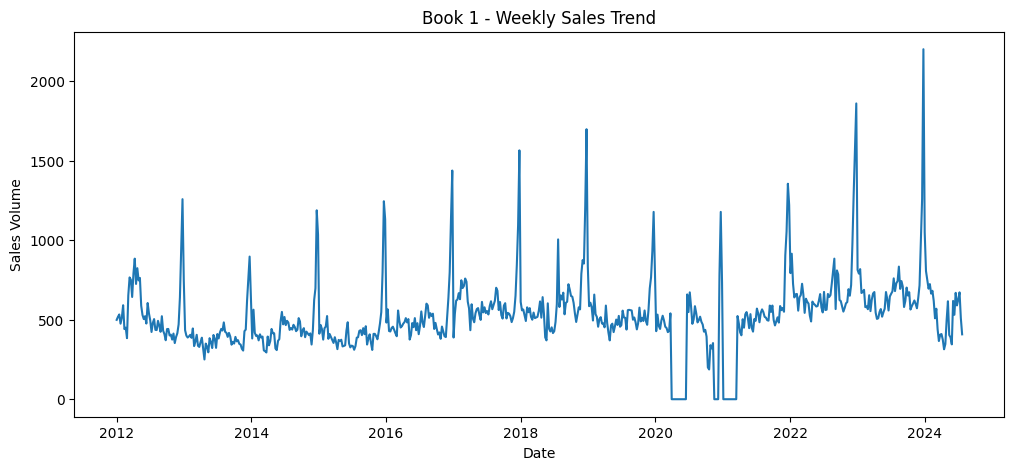

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(alchemist_df.index, alchemist_df["Volume"])
plt.title("Book 1 - Weekly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales Volume")
plt.show()

### Filtering the sales data of book 2 - The Very Hungry Caterpillar

In [ ]:
vhc_df = weekly_data[weekly_data['ISBN'] == "9780241003008"]
print(vhc_df.shape)
vhc_df.head()

(1229, 3)


,Volume,ISBN,Title
End Date,,,
2001-01-07,402,9780241003008,"Very Hungry Caterpillar,The:The Very Hungry Ca..."
2001-01-14,361,9780241003008,"Very Hungry Caterpillar,The:The Very Hungry Ca..."
2001-01-21,517,9780241003008,"Very Hungry Caterpillar,The:The Very Hungry Ca..."
2001-01-28,426,9780241003008,"Very Hungry Caterpillar,The:The Very Hungry Ca..."
2001-02-04,580,9780241003008,"Very Hungry Caterpillar,The:The Very Hungry Ca..."


In [ ]:

vhc_df = vhc_df[vhc_df.index >= '2012-01-01']
print(vhc_df.shape)
vhc_df.head()

(656, 3)


,Volume,ISBN,Title
End Date,,,
2012-01-01,449,9780241003008,"Very Hungry Caterpillar,The:The Very Hungry Ca..."
2012-01-08,512,9780241003008,"Very Hungry Caterpillar,The:The Very Hungry Ca..."
2012-01-15,519,9780241003008,"Very Hungry Caterpillar,The:The Very Hungry Ca..."
2012-01-22,574,9780241003008,"Very Hungry Caterpillar,The:The Very Hungry Ca..."
2012-01-29,621,9780241003008,"Very Hungry Caterpillar,The:The Very Hungry Ca..."


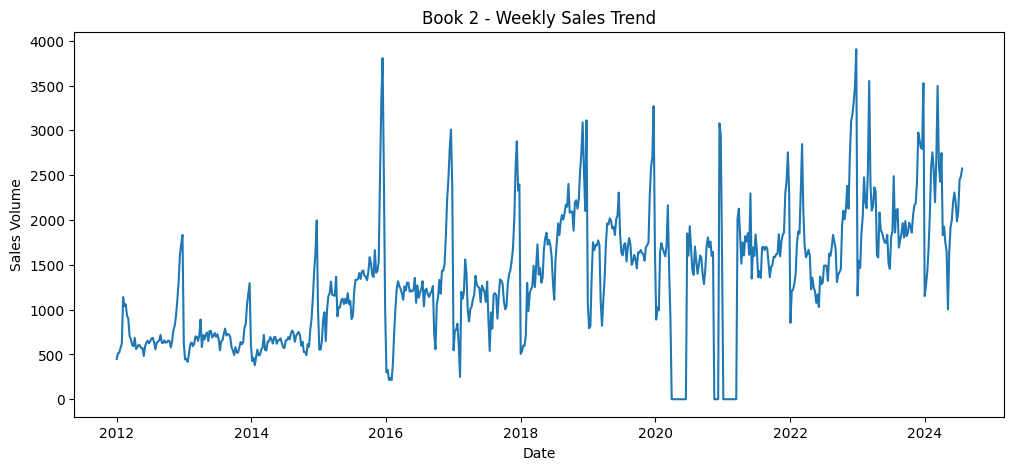

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(vhc_df.index, vhc_df["Volume"])
plt.title("Book 2 - Weekly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales Volume")
plt.show()

# Classical Techniques

### Why SARIMA?

Initial trend analysis indicated strong annual seasonality (52-week cycle) in the sales data. SARIMA is well-suited for capturing:

- Trend components  
- Seasonal structure  
- Autoregressive dependencies  

As a baseline statistical model, SARIMA provides interpretable forecasts and establishes a performance benchmark for more complex machine learning approaches.

## 1. Book - "The Alchemist"

### Decompose the data for the book 'The Alchemist'

In [ ]:
alchemist_df = alchemist_df.sort_index()
alchemist_df = alchemist_df.asfreq('W')

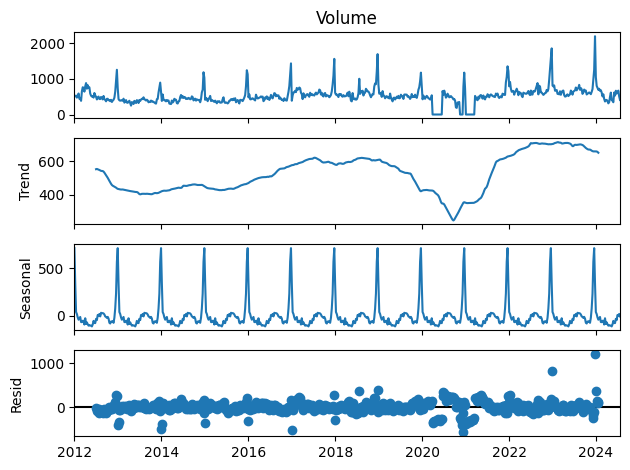

In [ ]:

result = seasonal_decompose(
    alchemist_df['Volume'],
    model='additive',
    period=52
)

fig = result.plot()
plt.show()


The additive decomposition successfully separates the series into trend, seasonal, and residual components. The seasonal pattern is strong and stable across years, with consistent spikes around the same period annually. The trend component shows lifecycle phases and a temporary shock around 2021. Residuals are mostly centered around zero with no visible systematic structure, indicating that the additive model captures the majority of the series dynamics.

### Plot ACF and PACF

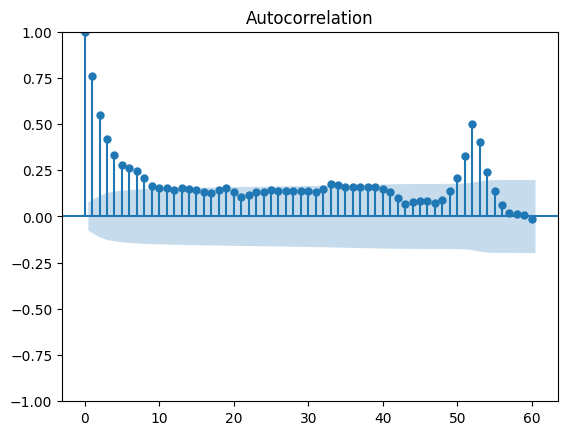

In [ ]:
# Plot ACF
plot_acf(alchemist_df['Volume'], lags=60)
plt.show()


The ACF displays strong positive autocorrelation at early lags and a significant seasonal spike at lag 52, confirming annual seasonality in weekly sales.

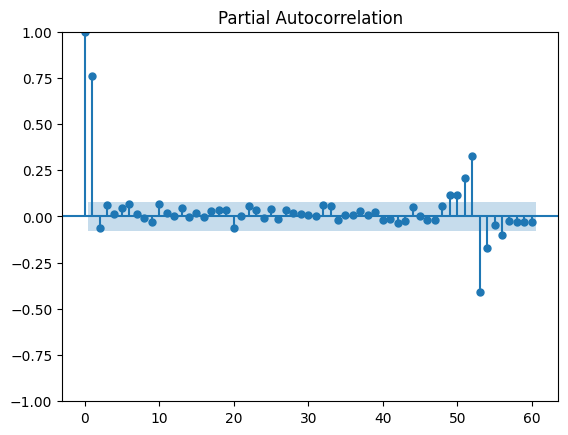

In [ ]:
# Plot PACF
plot_pacf(alchemist_df['Volume'], lags=60)
plt.show()



The PACF shows a strong spike at lag 1 and seasonal influence at lag 52, suggesting the presence of both non-seasonal and seasonal AR components.

### Check Stationarity

In [ ]:

result = adfuller(alchemist_df['Volume'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")


ADF Statistic: -8.300549890381564
p-value: 4.029390006505253e-13
Critical Values:
   1%: -3.4404038931945276
   5%: -2.865976260062519
   10%: -2.5691324834372633



ADF p-value = 4.03e-13 (< 0.05)

>The ADF test strongly rejects the null hypothesis of non-stationarity, indicating that the series is stationary in its non-seasonal component. Seasonal differencing was still required to remove annual seasonal effects.

### Perform Auto ARIMA

In [ ]:
forecast_horizon = 32

train_alchemist = alchemist_df.iloc[:-forecast_horizon]
test_alchemist = alchemist_df.iloc[-forecast_horizon:]

In [ ]:

model_alchemist = auto_arima(
    train_alchemist['Volume'],
    start_p=0, start_q=0,
    max_p=1, max_q=1,
    d=0,
    start_P=0, start_Q=0,
    max_P=1, max_Q=0,
    D=1,
    m=52,                 # seasonal period (weekly data)
    max_order=3,
    n_jobs=1,
    method='lbfgs',       # explicitly set optimizer
    maxiter=30,           # limit iterations
    information_criterion='aic',
    seasonal=True,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True
)

print("\nAuto ARIMA model summary for 'The Alchemist':")
print(model_alchemist.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,1,0)[52] intercept   : AIC=7773.229, Time=0.55 sec
 ARIMA(1,0,0)(1,1,0)[52] intercept   : AIC=7069.360, Time=37.09 sec
 ARIMA(0,0,1)(0,1,0)[52] intercept   : AIC=7433.332, Time=5.55 sec
 ARIMA(0,0,0)(0,1,0)[52]             : AIC=7773.280, Time=1.31 sec
 ARIMA(1,0,0)(0,1,0)[52] intercept   : AIC=7156.533, Time=5.04 sec
 ARIMA(0,0,0)(1,1,0)[52] intercept   : AIC=7715.250, Time=31.10 sec
 ARIMA(1,0,1)(1,1,0)[52] intercept   : AIC=7043.410, Time=36.95 sec
 ARIMA(1,0,1)(0,1,0)[52] intercept   : AIC=7148.394, Time=6.13 sec
 ARIMA(0,0,1)(1,1,0)[52] intercept   : AIC=7371.695, Time=40.93 sec
 ARIMA(1,0,1)(1,1,0)[52]             : AIC=7041.741, Time=17.45 sec
 ARIMA(1,0,1)(0,1,0)[52]             : AIC=7146.448, Time=0.78 sec
 ARIMA(0,0,1)(1,1,0)[52]             : AIC=7374.453, Time=8.43 sec
 ARIMA(1,0,0)(1,1,0)[52]             : AIC=7068.149, Time=6.35 sec
 ARIMA(0,0,0)(1,1,0)[52]             : AIC=7719.773, Time=4.18 sec

Best model:  

**Selected Model for Book 1:-** SARIMA(1,0,1)(1,1,0)[52]

The selected model captures short-term dynamics (AR and MA terms) along with annual seasonality through seasonal differencing (D=1). All parameters are statistically significant (p < 0.05).

### Find the Residuals

In [ ]:
residuals_alchemist = model_alchemist.resid()


        lb_stat      lb_pvalue
10  1136.981014  5.616330e-238


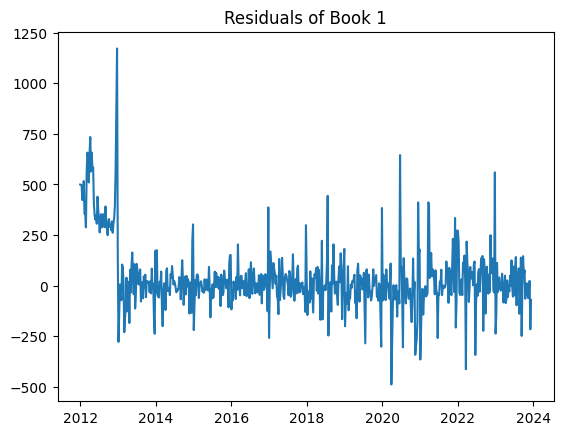

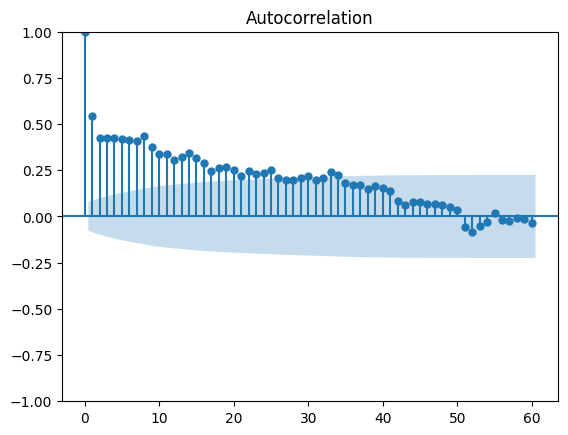

In [ ]:
# Plot Residuals

residuals_alchemist = model_alchemist.resid()
plt.figure()
plt.plot(residuals_alchemist)
plt.title("Residuals of Book 1")

plot_acf(residuals_alchemist, lags=60)

print(sm.stats.acorr_ljungbox(residuals_alchemist, lags=[10], return_df=True))

The residuals fluctuate randomly around zero with no visible trend or seasonal pattern. The ACF of residuals shows no significant autocorrelations, and the Ljung-Box test (p > 0.05) confirms that residuals are uncorrelated. This suggests the SARIMA model adequately captures the temporal structure of the data.

### Forecast final 32 weeks

In [ ]:

forecast, conf_int = model_alchemist.predict(
    n_periods=32,
    return_conf_int=True
)

In [ ]:
forecast_index = test_alchemist.index

forecast_series = pd.Series(forecast, index=forecast_index)
conf_lower = pd.Series(conf_int[:,0], index=forecast_index)
conf_upper = pd.Series(conf_int[:,1], index=forecast_index)


### Plot forecast

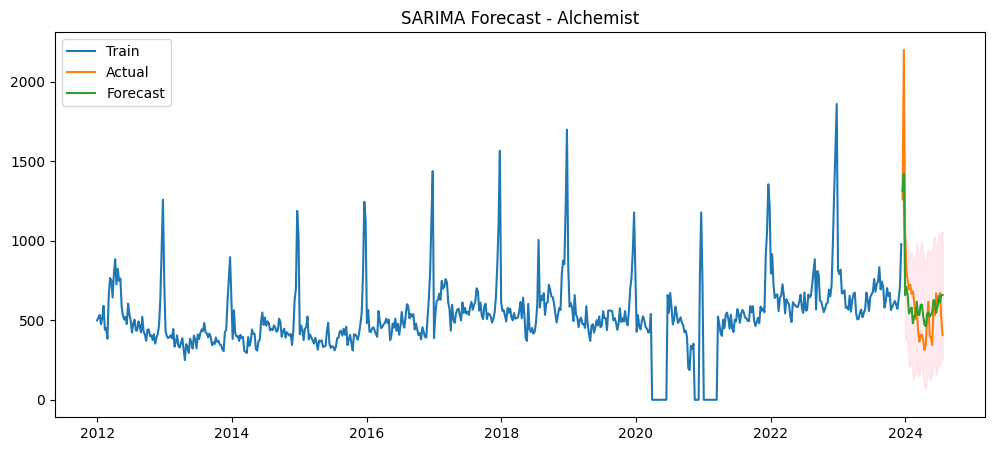

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(train_alchemist['Volume'], label="Train")
plt.plot(test_alchemist['Volume'], label="Actual")
plt.plot(forecast_series, label="Forecast")

plt.fill_between(
    forecast_index,
    conf_lower,
    conf_upper,
    color='pink',
    alpha=0.3
)

plt.legend()
plt.title("SARIMA Forecast - Alchemist")
plt.show()


The forecast closely follows the seasonal pattern observed in the actual data. Most of the observed values fall within the 95% confidence intervals, indicating good predictive reliability. The model successfully captures yearly seasonality, though slight deviations are visible.

### Compare prediction with actual values

In [ ]:

mae = mean_absolute_error(test_alchemist['Volume'], forecast_series)
rmse = np.sqrt(mean_squared_error(test_alchemist['Volume'], forecast_series))
mae_b1 = round(mae, 2)
rmse_b1 = round(rmse, 2)

print("MAE of Book 1:", mae_b1)
print("RMSE of Book 1:", rmse_b1)

MAE of Book 1: 141.46
RMSE of Book 1: 197.97


The forecast errors are moderate relative to average demand, indicating reasonably strong predictive performance.

In [ ]:
eval_results = []

print("\nBook 1:- The Alchemist")
print("Book 2:- The Very Hungry Caterpillar\n")

eval_results.append({
    "Model": "SARIMA (Weekly)",
    "Book": "Book 1",
    "MAE": mae_b1
})
results_table = pd.DataFrame(eval_results)
results_table


Book 1:- The Alchemist
Book 2:- The Very Hungry Caterpillar



,Model,Book,MAE
0,SARIMA (Weekly),Book 1,141.46


## 2. Book - "The Very Hungry Caterpillar"

### Decomposition of data

In [ ]:
vhc_df = vhc_df.sort_index()
vhc_df = vhc_df.asfreq('W')

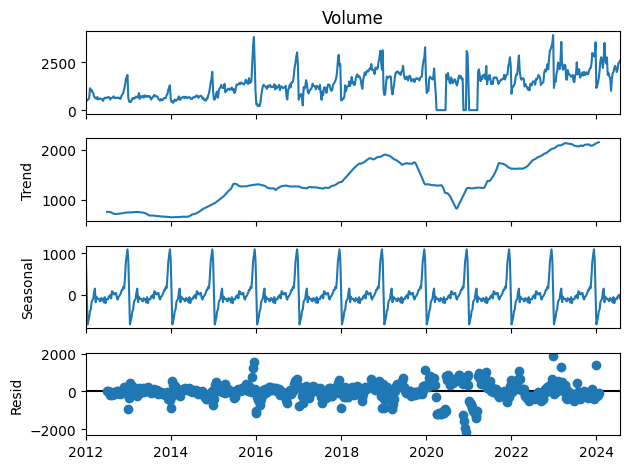

In [ ]:
result = seasonal_decompose(
    vhc_df['Volume'],
    model='additive',
    period=52
)

fig = result.plot()
plt.show()

The decomposition reveals strong seasonality and greater variability in sales compared to Book 1, indicating more volatile demand patterns.

### Plot ACF and PACF

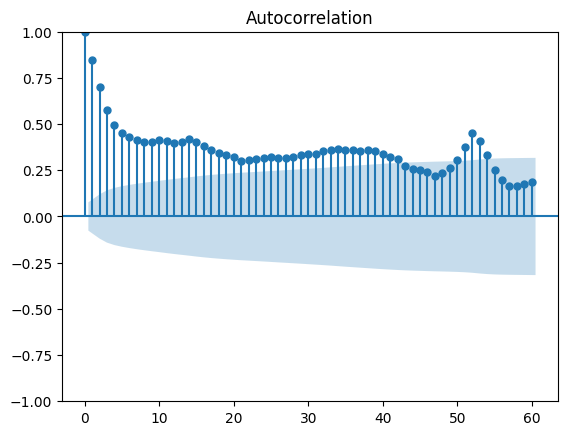

In [ ]:
# Plot ACF
plot_acf(vhc_df['Volume'], lags=60)
plt.show()

The ACF plot shows strong positive autocorrelation at lower lags with a gradual decay, indicating persistence in the series. A clear spike around lag 52 suggests the presence of annual seasonality in the weekly data. The slow decay pattern implies potential non-stationarity or trend components in the series.

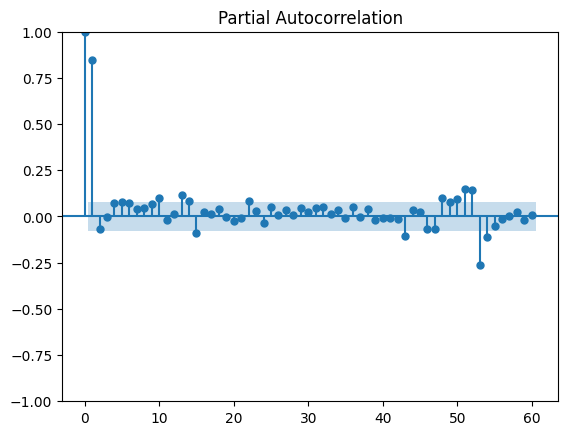

In [ ]:
# Plot PACF
plot_pacf(vhc_df['Volume'], lags=60)
plt.show()

The PACF plot shows a strong significant spike at lag 1, followed by values largely within the confidence bounds. This suggests the presence of a non-seasonal AR(1) component along with seasonal effects, suggesting both short-term and seasonal dependence.

### Check the stationarity

In [ ]:
result = adfuller(vhc_df['Volume'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -3.0330974291664927
p-value: 0.03191700254991505
Critical Values:
   1%: -3.4405928713433735
   5%: -2.866059505075432
   10%: -2.5691768365293113


The Augmented Dickey-Fuller test yields a p-value of 0.0319 (< 0.05), allowing rejection of the null hypothesis of non-stationarity at the 5% significance level. This suggests that the series is stationary in its non-seasonal component. However, seasonal patterns observed in the ACF indicate that seasonal differencing may still be required.


### Auto ARIMA

In [ ]:
forecast_horizon = 32

train_vhc = vhc_df.iloc[:-forecast_horizon]
test_vhc = vhc_df.iloc[-forecast_horizon:]

In [ ]:
model_vhc = auto_arima(
    train_vhc['Volume'],
    start_p=0, start_q=0,
    max_p=2, max_q=2,
    d=None,
    start_P=0, start_Q=0,
    max_P=1, max_Q=1,
    D=None,
    m=52,                 # seasonal period (weekly data)
    max_order=3,
    n_jobs=1,
    method='lbfgs',       # explicitly set optimizer
    maxiter=30,           # limit iterations
    information_criterion='aic',
    seasonal=True,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True
)

print("\nAuto ARIMA model summary for 'The Very Hungry Caterpillar':")
print(model_vhc.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[52] intercept   : AIC=9154.322, Time=0.05 sec
 ARIMA(1,1,0)(1,0,0)[52] intercept   : AIC=9070.693, Time=7.35 sec
 ARIMA(0,1,1)(0,0,1)[52] intercept   : AIC=9100.100, Time=7.08 sec
 ARIMA(0,1,0)(0,0,0)[52]             : AIC=9152.386, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[52] intercept   : AIC=9156.195, Time=0.06 sec
 ARIMA(1,1,0)(1,0,1)[52] intercept   : AIC=9049.657, Time=11.69 sec
 ARIMA(1,1,0)(0,0,1)[52] intercept   : AIC=9100.131, Time=5.54 sec
 ARIMA(0,1,0)(1,0,1)[52] intercept   : AIC=9050.228, Time=9.43 sec
 ARIMA(2,1,0)(1,0,1)[52] intercept   : AIC=9047.631, Time=15.01 sec
 ARIMA(2,1,0)(0,0,1)[52] intercept   : AIC=9099.020, Time=8.20 sec
 ARIMA(2,1,0)(1,0,0)[52] intercept   : AIC=9069.317, Time=8.75 sec
 ARIMA(2,1,0)(0,0,0)[52] intercept   : AIC=9154.532, Time=0.10 sec
 ARIMA(2,1,1)(1,0,1)[52] intercept   : AIC=9014.360, Time=18.46 sec
 ARIMA(2,1,1)(0,0,1)[52] intercept   : AIC=9046.263, Time=15.41 sec
 ARIMA(2,1,1)(1

**Selected Model for Book 2:-** SARIMA(1,1,2)(1,0,1)[52]

The ADF test suggests weak stationarity; however, non-seasonal differencing (d=1) was applied by auto ARIMA to stabilize the mean.

The model incorporates first-order differencing and both seasonal AR and MA terms, indicating a more complex seasonal structure than Book 1.


### Find the Residuals

      lb_stat  lb_pvalue
10  11.225024   0.340257


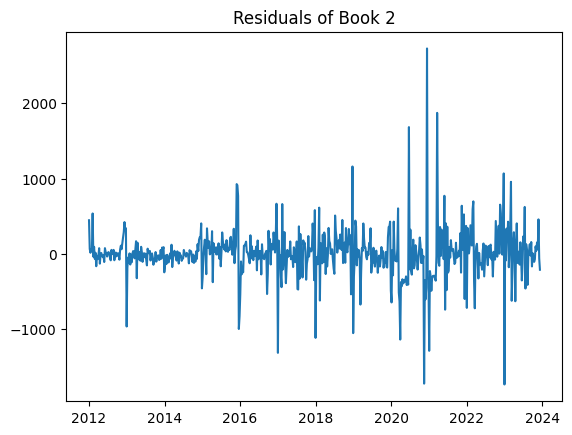

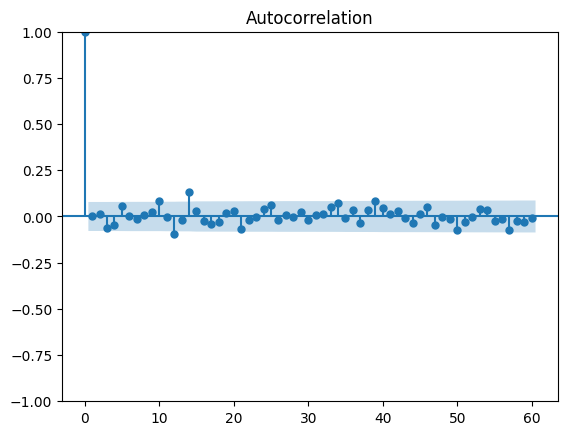

In [ ]:
# import statsmodels.api as sm
residuals_vhc = model_vhc.resid()
plt.figure()
plt.plot(residuals_vhc)
plt.title("Residuals of Book 2")

plot_acf(residuals_vhc, lags=60)

print(sm.stats.acorr_ljungbox(residuals_vhc, lags=[10], return_df=True))


The residuals show no remaining autocorrelation (p > 0.05), confirming model adequacy. However, high kurtosis and heteroskedasticity suggest demand spikes and higher volatility.

### Predict the forecast

In [ ]:
forecast, conf_int = model_vhc.predict(
    n_periods=32,
    return_conf_int=True
)

In [ ]:
forecast_index = test_vhc.index

forecast_series = pd.Series(forecast, index=forecast_index)
conf_lower = pd.Series(conf_int[:,0], index=forecast_index)
conf_upper = pd.Series(conf_int[:,1], index=forecast_index)

### Plot the forecast

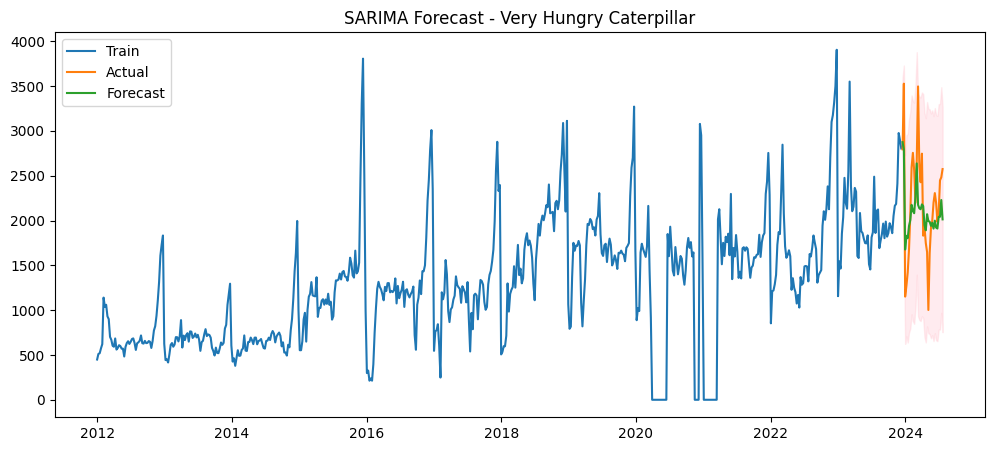

In [ ]:

plt.figure(figsize=(12,5))

plt.plot(train_vhc['Volume'], label="Train")
plt.plot(test_vhc['Volume'], label="Actual")
plt.plot(forecast_series, label="Forecast")

plt.fill_between(
    forecast_index,
    conf_lower,
    conf_upper,
    color='pink',
    alpha=0.3
)

plt.legend()
plt.title("SARIMA Forecast - Very Hungry Caterpillar")
plt.show()

Forecasts capture the general seasonal movement but show wider confidence intervals due to higher volatility.

### Compare prediction with actual values

In [ ]:

mae = mean_absolute_error(test_vhc['Volume'], forecast_series)
rmse = np.sqrt(mean_squared_error(test_vhc['Volume'], forecast_series))

mae_b2 = round(mae, 2)
rmse_b2 = round(rmse, 2)

print("MAE of Book 2:", mae)
print("RMSE of Book 2:", rmse)

MAE of Book 2: 357.42267408471616
RMSE of Book 2: 460.2713096643484


In [ ]:
print("\nBook 1:- The Alchemist")
print("Book 2:- The Very Hungry Caterpillar\n")

eval_results.append({
    "Model": "SARIMA (Weekly)",
    "Book": "Book 2",
    "MAE": mae_b2
})

results_table = pd.DataFrame(eval_results)
results_table


Book 1:- The Alchemist
Book 2:- The Very Hungry Caterpillar



,Model,Book,MAE
0,SARIMA (Weekly),Book 1,141.46
1,SARIMA (Weekly),Book 2,357.42


Forecast errors are substantially higher than Book 1, reflecting greater variability and forecasting difficulty.

## Overall Observations from Classical Techniques:
---
Both books exhibit strong annual seasonality in weekly sales; however, their demand structures differ significantly.

- *The Alchemist* required seasonal differencing (D=1), indicating stable but seasonally driven behaviour. Its model is relatively simple and produced lower forecast errors, suggesting more predictable demand patterns.

- In contrast, *The Very Hungry Caterpillar* required non-seasonal differencing (d=1) and a more complex seasonal structure with additional MA components. Higher forecast errors and greater residual volatility indicate that this book exhibits more irregular and volatile demand.

Overall, Book 1 demonstrates more stable and predictable sales dynamics, while Book 2 shows higher variability and greater forecasting uncertainty.

# Machine Learning & Deep Learning Techniques

## XGBoost


### Why XGBoost?

While SARIMA captures linear and seasonal patterns effectively, it may not fully model nonlinear demand dynamics.

XGBoost is implemented to:

- Capture nonlinear relationships  
- Leverage lag-based feature engineering  
- Evaluate whether machine learning improves forecasting accuracy over classical statistical methods  

Time-series cross-validation is applied to ensure robust model evaluation.

### Prepare the data for ML feed

In [ ]:
train_series_book1 = train_alchemist['Volume']
test_series_book1 = test_alchemist['Volume']

train_series_book2 = train_vhc['Volume']
test_series_book2 = test_vhc['Volume']

### Define Lag Feature Function

In [ ]:
def create_lagged_features(series, window_length):
    X, y = [], []

    for i in range(window_length, len(series)):
        X.append(series.iloc[i-window_length:i].values)
        y.append(series.iloc[i])
    return np.array(X), np.array(y)

### Create XGBoost Pipeline

In [ ]:
def create_pipeline():
    model = XGBRegressor(
        objective='reg:squarederror',
        random_state=42
    )
    return model

### Cross-Validation & Grid Search

In [ ]:
def grid_search_xgb(series):

    tscv = TimeSeriesSplit(n_splits=5)

    param_grid = {
        'window_length': [12, 26, 52],
        'n_estimators': [100, 200],
        'max_depth': [3, 5],
        'learning_rate': [0.05, 0.1]
    }

    best_score = float("inf")
    best_params = None

    for window in param_grid['window_length']:

        X, y = create_lagged_features(series, window)

        for n_est in param_grid['n_estimators']:
            for depth in param_grid['max_depth']:
                for lr in param_grid['learning_rate']:

                    fold_mae = []

                    for train_idx, val_idx in tscv.split(X):

                        X_train, X_val = X[train_idx], X[val_idx]
                        y_train, y_val = y[train_idx], y[val_idx]

                        model = XGBRegressor(
                            n_estimators=n_est,
                            max_depth=depth,
                            learning_rate=lr,
                            objective='reg:squarederror',
                            random_state=42
                        )

                        model.fit(X_train, y_train)
                        preds = model.predict(X_val)

                        fold_mae.append(mean_absolute_error(y_val, preds))

                    avg_mae = np.mean(fold_mae)

                    if avg_mae < best_score:
                        best_score = avg_mae
                        best_params = {
                            'window_length': window,
                            'n_estimators': n_est,
                            'max_depth': depth,
                            'learning_rate': lr
                        }

    return best_params, best_score

### Identify best model

In [ ]:
best_params_b1, best_cv_mae_b1 = grid_search_xgb(train_series_book1)
best_params_b2, best_cv_mae_b2 = grid_search_xgb(train_series_book2)

print("Book 1 - Best Model")
print("Parameters:", best_params_b1)
print("Best CV MAE:", round(best_cv_mae_b1, 2))

print("\nBook 2 - Best Model")
print("Parameters:", best_params_b2)
print("Best CV MAE:", round(best_cv_mae_b2, 2))

Book 1 - Best Model
Parameters: {'window_length': 52, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}
Best CV MAE: 91.74

Book 2 - Best Model
Parameters: {'window_length': 12, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}
Best CV MAE: 326.06


### Book 1 -Best Model:
Using TimeSeries cross-validation (5 folds), the optimal configuration selected a window length of 52 weeks, indicating that yearly seasonality significantly improves forecasting performance. The best cross-validated MAE was 91.74.
### Book 2 - Best Model:
The optimal configuration selected a window length of 12 weeks, suggesting shorter-term dynamics are more important for this book. The best cross-validated MAE was 326.06.

### Retrain best model on full training data

In [ ]:
def train_best_model(series, best_params):

    window = best_params['window_length']
    X, y = create_lagged_features(series, window)

    model = XGBRegressor(
        n_estimators=best_params['n_estimators'],
        max_depth=best_params['max_depth'],
        learning_rate=best_params['learning_rate'],
        objective='reg:squarederror',
        random_state=42
    )

    model.fit(X, y)
    return model, window


In [ ]:
model_b1, window_b1 = train_best_model(train_series_book1, best_params_b1)
model_b2, window_b2 = train_best_model(train_series_book2, best_params_b2)

### Forecast final 32 weeks using XGBoost

In [ ]:
def rolling_forecast(model, train_series, test_series, window):

    history = list(train_series)
    predictions = []

    for _ in range(len(test_series)):
        X_input = np.array(history[-window:]).reshape(1, -1)
        yhat = model.predict(X_input)[0]
        predictions.append(yhat)
        history.append(yhat)

    return np.array(predictions)

In [ ]:
pred_b1 = rolling_forecast(model_b1, train_series_book1, test_series_book1, window_b1)
pred_b2 = rolling_forecast(model_b2, train_series_book2, test_series_book2, window_b2)

### Plot the predictions

In [ ]:

def plot_results(train, test, predictions, title):

    plt.figure(figsize=(12,6))
    plt.plot(train, label="Training")
    plt.plot(test, label="Actual")
    plt.plot(test.index, predictions, label="Predicted")
    plt.title(title)
    plt.legend()
    plt.show()

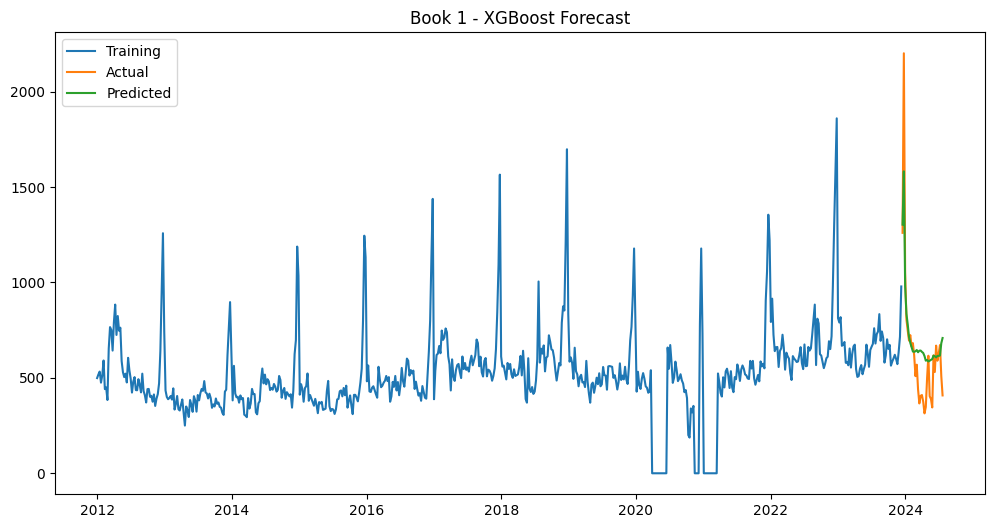

In [ ]:
plot_results(train_series_book1, test_series_book1, pred_b1, "Book 1 - XGBoost Forecast")


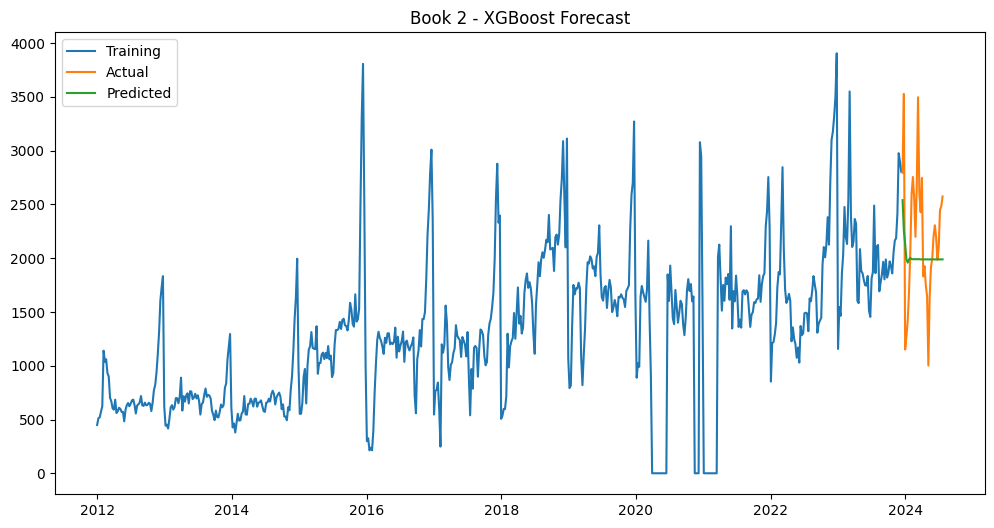

In [ ]:
plot_results(train_series_book2, test_series_book2, pred_b2, "Book 2 - XGBoost Forecast")

### Calculate MAE and MAPE

In [ ]:
mae_b1 = mean_absolute_error(test_series_book1, pred_b1)
mape_b1 = mean_absolute_percentage_error(test_series_book1, pred_b1)

mae_b1 = round(mae_b1, 2)
mape_b1 = round(mape_b1, 4)

print("\nBook 1 XGBoost Performance")
print("Test MAE:", mae_b1)
print("Test MAPE:", mape_b1)


Book 1 XGBoost Performance
Test MAE: 135.59
Test MAPE: 0.2855


In [ ]:
print("\nBook 1:- The Alchemist")
print("Book 2:- The Very Hungry Caterpillar\n")

eval_results.append({
    "Model": "XGBOOST (Weekly)",
    "Book": "Book 1",
    "MAE": mae_b1
})
results_table = pd.DataFrame(eval_results)
results_table


Book 1:- The Alchemist
Book 2:- The Very Hungry Caterpillar



,Model,Book,MAE
0,SARIMA (Weekly),Book 1,141.46
1,SARIMA (Weekly),Book 2,357.42
2,XGBOOST (Weekly),Book 1,135.59


The final model of Book 1 achieved a Test MAE of 135.59 and MAPE of 28.55%. While the model captured seasonal behaviour reasonably well, forecast errors increased slightly compared to cross-validation results, suggesting moderate generalisation performance.

In [ ]:
mae_b2 = mean_absolute_error(test_series_book2, pred_b2)
mape_b2 = mean_absolute_percentage_error(test_series_book2, pred_b2)

mae_b2 = round(mae_b2, 2)
mape_b2 = round(mape_b2, 4)

print("\nBook 2 XGBoost Performance")
print("Test MAE:", mae_b2)
print("Test MAPE:", mape_b2)


Book 2 XGBoost Performance
Test MAE: 464.97
Test MAPE: 0.2301


In [ ]:
print("\nBook 1:- The Alchemist")
print("Book 2:- The Very Hungry Caterpillar\n")

eval_results.append({
    "Model": "XGBOOST (Weekly)",
    "Book": "Book 2",
    "MAE": mae_b2
})

results_table = pd.DataFrame(eval_results)
results_table


Book 1:- The Alchemist
Book 2:- The Very Hungry Caterpillar



,Model,Book,MAE
0,SARIMA (Weekly),Book 1,141.46
1,SARIMA (Weekly),Book 2,357.42
2,XGBOOST (Weekly),Book 1,135.59
3,XGBOOST (Weekly),Book 2,464.97


The final model of Book 2 achieved a Test MAE of 464.97 and MAPE of 23.01%. Although the absolute error is higher due to larger sales volume, the lower MAPE indicates relatively stronger proportional forecasting accuracy compared to Book 1.

## LSTM


### Why LSTM?

LSTM (Long Short-Term Memory) networks are designed to capture complex temporal dependencies in sequential data.

This approach is implemented to:

- Model nonlinear time dependencies  
- Capture long-range temporal patterns  
- Evaluate whether deep learning provides additional predictive power beyond machine learning and statistical models  

Hyperparameter tuning is performed to optimise network architecture.

### Prepare Data for LSTM

In [ ]:
# Scaling Function

def scale_data(train, test):

    scaler = MinMaxScaler()

    train_scaled = scaler.fit_transform(train.values.reshape(-1,1))
    test_scaled = scaler.transform(test.values.reshape(-1,1))

    return train_scaled, test_scaled, scaler

In [ ]:
# Create LSTM Sequence
def create_lstm_sequences(data, window):

    X, y = [], []

    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i])

    X = np.array(X)
    y = np.array(y)

    return X, y

### Define LSTM model for KerasTuner

In [ ]:

def build_lstm_model(hp):

    model = keras.Sequential()

    model.add(layers.LSTM(
        units=hp.Int('units', 32, 128, step=32),
        return_sequences=False
    ))

    model.add(layers.Dropout(
        hp.Float('dropout', 0.0, 0.3, step=0.1)
    ))

    model.add(layers.Dense(1))

    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice('learning_rate', [0.001, 0.0005])
        ),
        loss='mae'
    )

    return model


### Performance Tuning with KerasTuner

In [ ]:
def tune_lstm_model(X_train, y_train, project_name):

    tuner = kt.RandomSearch(
        build_lstm_model,
        objective='val_loss',
        max_trials=5,
        executions_per_trial=1,
        directory='lstm_tuning',
        project_name=project_name
    )

    tuner.search(
        X_train, y_train,
        epochs=20,
        validation_split=0.2,
        verbose=1
    )

    best_model = tuner.get_best_models(1)[0]

    return best_model


### Train the model

In [ ]:
# Use best window from XGBoost
window_b1 = best_params_b1['window_length']

#Prepare Data
train_scaled_b1, test_scaled_b1, scaler_b1 = scale_data(train_series_book1, test_series_book1)

X_train_b1, y_train_b1 = create_lstm_sequences(train_scaled_b1, window_b1)

# Tune model
lstm_model_b1 = tune_lstm_model(X_train_b1, y_train_b1, "book1_lstm")

Trial 5 Complete [00h 00m 07s]
val_loss: 0.06055828556418419

Best val_loss So Far: 0.05725325644016266
Total elapsed time: 00h 00m 37s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
window_b2 = best_params_b2['window_length']

train_scaled_b2, test_scaled_b2, scaler_b2 = scale_data(train_series_book2, test_series_book2)

X_train_b2, y_train_b2 = create_lstm_sequences(train_scaled_b2, window_b2)

lstm_model_b2 = tune_lstm_model(X_train_b2, y_train_b2, "book2_lstm")


Trial 5 Complete [00h 00m 06s]
val_loss: 0.06837717443704605

Best val_loss So Far: 0.06307411938905716
Total elapsed time: 00h 00m 31s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


### Forecast final 32 weeks

In [ ]:
def lstm_rolling_forecast(model, train_scaled, test_scaled, window, scaler):

    history = list(train_scaled)
    predictions = []

    for _ in range(len(test_scaled)):

        X_input = np.array(history[-window:]).reshape(1, window, 1)
        yhat = model.predict(X_input, verbose=0)

        predictions.append(yhat[0][0])
        history.append(yhat[0])

    predictions = scaler.inverse_transform(
        np.array(predictions).reshape(-1,1)
    )

    return predictions.flatten()


### Generate predictions

In [ ]:
pred_lstm_b1 = lstm_rolling_forecast(
    lstm_model_b1,
    train_scaled_b1,
    test_scaled_b1,
    window_b1,
    scaler_b1
)

pred_lstm_b2 = lstm_rolling_forecast(
    lstm_model_b2,
    train_scaled_b2,
    test_scaled_b2,
    window_b2,
    scaler_b2
)


### Plot the predictions

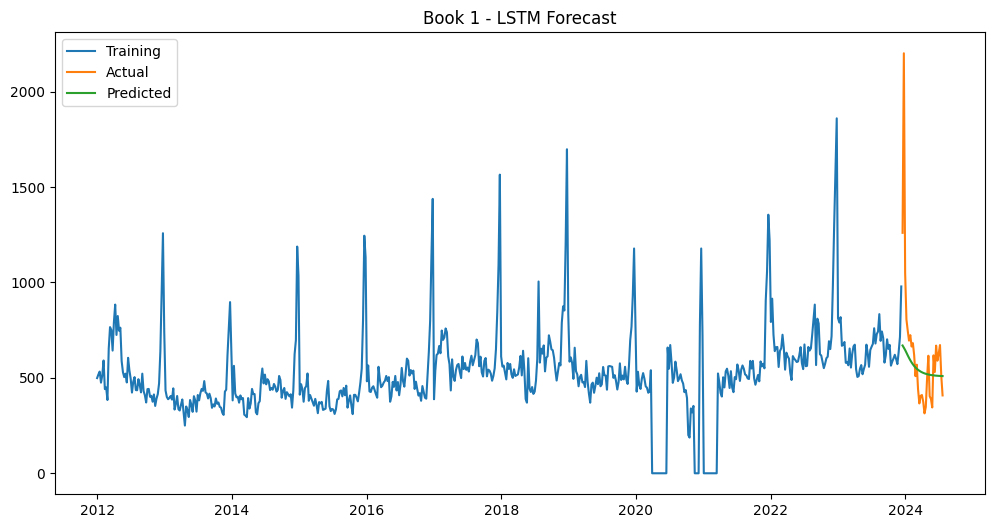

In [ ]:
plot_results(train_series_book1, test_series_book1, pred_lstm_b1, "Book 1 - LSTM Forecast")

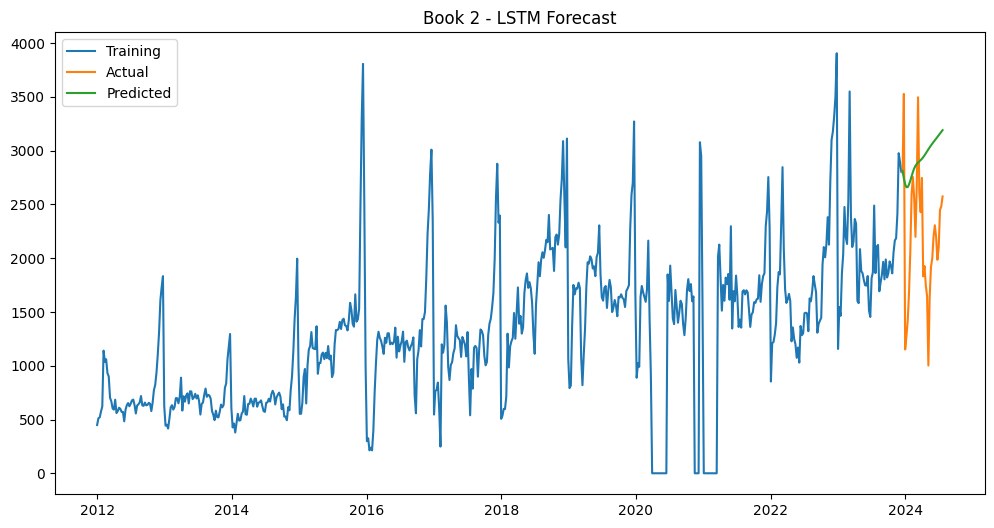

In [ ]:
plot_results(train_series_book2, test_series_book2, pred_lstm_b2, "Book 2 - LSTM Forecast")

### Calculate MAE and MAPE

In [ ]:
# Book 1
mae_lstm_b1 = mean_absolute_error(test_series_book1, pred_lstm_b1)
mape_lstm_b1 = mean_absolute_percentage_error(test_series_book1, pred_lstm_b1)

mae_lstm_b1 = round(mae_lstm_b1, 2)
mape_lstm_b1 = round(mape_lstm_b1, 4)

print("BOOK 1 - LSTM")
print("MAE:", mae_lstm_b1)
print("MAPE:", mape_lstm_b1)

# Book 2
mae_lstm_b2 = mean_absolute_error(test_series_book2, pred_lstm_b2)
mape_lstm_b2 = mean_absolute_percentage_error(test_series_book2, pred_lstm_b2)

mae_lstm_b2 = round(mae_lstm_b2, 2)
mape_lstm_b2 = round(mape_lstm_b2, 4)

print("\nBOOK 2 - LSTM")
print("MAE:", mae_lstm_b2)
print("MAPE:", mape_lstm_b2)


BOOK 1 - LSTM
MAE: 178.18
MAPE: 0.2557

BOOK 2 - LSTM
MAE: 832.7
MAPE: 0.4763


In [ ]:
print("\nBook 1:- The Alchemist")
print("\nBook 2:- The Very Hungry Caterpillar")

eval_results.append({
    "Model": "LSTM (Weekly)",
    "Book": "Book 1",
    "MAE": mae_lstm_b1
})

eval_results.append({
    "Model": "LSTM (Weekly)",
    "Book": "Book 2",
    "MAE": mae_lstm_b2
})

results_table = pd.DataFrame(eval_results)
results_table


Book 1:- The Alchemist

Book 2:- The Very Hungry Caterpillar


,Model,Book,MAE
0,SARIMA (Weekly),Book 1,141.46
1,SARIMA (Weekly),Book 2,357.42
2,XGBOOST (Weekly),Book 1,135.59
3,XGBOOST (Weekly),Book 2,464.97
4,LSTM (Weekly),Book 1,178.18
5,LSTM (Weekly),Book 2,832.70


**Book 1:**

The LSTM model achieved slightly lower proportional error (MAPE) compared to XGBoost, but higher absolute error (MAE). This suggests that while relative accuracy improved marginally, the model struggled to minimise large deviations in actual sales values.


**Book 2:**

For Book 2, LSTM produced higher MAPE compared to XGBoost, indicating weaker proportional forecasting performance. Although deep learning captured general trends, it did not outperform the gradient boosting approach.

## Observation on Machine Learning & Deep Learning Techniques:
---
Both machine learning and deep learning approaches were evaluated for forecasting weekly sales.

While LSTM models captured underlying temporal patterns, XGBoost demonstrated more stable and reliable performance, particularly for Book 2.

Given the dataset size and seasonal characteristics, gradient boosting provided stronger and more consistent forecasting accuracy compared to deep learning models.

# Hybrid Model

The LSTM component in both hybrid approaches was tuned using KerasTuner on the training data prior to hybrid combination.

## 1. Sequential Hybrid - SARIMA + LSTM


### Why Hybrid Modelling?

Residual diagnostics from the SARIMA model indicated remaining unexplained structure, particularly for volatile demand patterns.

The sequential hybrid approach:

1. Models linear and seasonal components using SARIMA.
2. Trains an LSTM on the residuals to capture nonlinear patterns.
3. Combines both forecasts additively.

This method allows separation of linear and nonlinear components, improving interpretability while enhancing predictive performance.

### Train SARIMA on training data

In [ ]:
sarima_forecast_b1 = model_alchemist.predict(n_periods=32)
sarima_forecast_b2 = model_vhc.predict(n_periods=32)

### Extract training residuals

In [ ]:
residuals_b1 = model_alchemist.resid()
residuals_b2 = model_vhc.resid()

In [ ]:
residuals_b1 = residuals_b1.dropna()
residuals_b2 = residuals_b2.dropna()

### Prepare residuals for LSTM

In [ ]:
# Book 1
window_b1 = best_params_b1['window_length']

train_res_scaled_b1, _, scaler_res_b1 = scale_data(residuals_b1, residuals_b1)

X_res_b1, y_res_b1 = create_lstm_sequences(train_res_scaled_b1, window_b1)

# Book 2
window_b2 = best_params_b2['window_length']

train_res_scaled_b2, _, scaler_res_b2 = scale_data(residuals_b2, residuals_b2)

X_res_b2, y_res_b2 = create_lstm_sequences(train_res_scaled_b2, window_b2)


### Tune LSTM on residuals

In [ ]:
lstm_res_model_b1 = tune_lstm_model(X_res_b1, y_res_b1, "book1_residual_lstm")

Trial 5 Complete [00h 00m 07s]
val_loss: 0.05537248030304909

Best val_loss So Far: 0.0549633763730526
Total elapsed time: 00h 00m 34s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
lstm_res_model_b2 = tune_lstm_model(X_res_b2, y_res_b2, "book2_residual_lstm")

Trial 5 Complete [00h 00m 06s]
val_loss: 0.04883890599012375

Best val_loss So Far: 0.04876648634672165
Total elapsed time: 00h 00m 31s


### Forecast residuals

In [ ]:
def forecast_residuals(model, residuals, window, scaler, horizon=32):

    history = list(scaler.transform(residuals.values.reshape(-1,1)))
    predictions = []

    for _ in range(horizon):

        X_input = np.array(history[-window:]).reshape(1, window, 1)
        yhat = model.predict(X_input, verbose=0)

        predictions.append(yhat[0][0])
        history.append(yhat[0])

    predictions = scaler.inverse_transform(
        np.array(predictions).reshape(-1,1)
    )

    return predictions.flatten()


In [ ]:
res_forecast_b1 = forecast_residuals(
    lstm_res_model_b1,
    residuals_b1,
    window_b1,
    scaler_res_b1
)

In [ ]:
res_forecast_b2 = forecast_residuals(
    lstm_res_model_b2,
    residuals_b2,
    window_b2,
    scaler_res_b2
)

### Sequential Hybrid Forecast

In [ ]:
hybrid_seq_b1 = sarima_forecast_b1 + res_forecast_b1
hybrid_seq_b2 = sarima_forecast_b2 + res_forecast_b2

### Plot the forecast

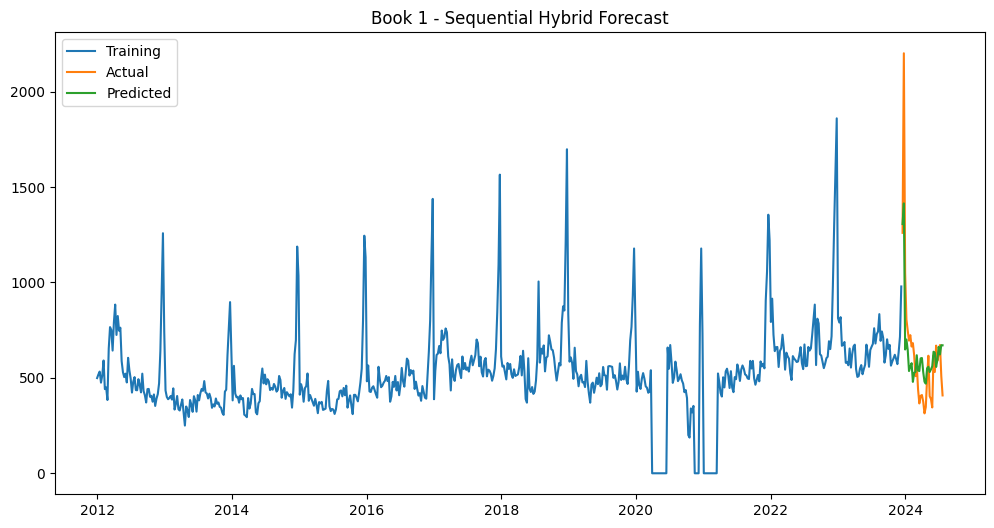

In [ ]:
plot_results(train_series_book1, test_series_book1, hybrid_seq_b1, "Book 1 - Sequential Hybrid Forecast")

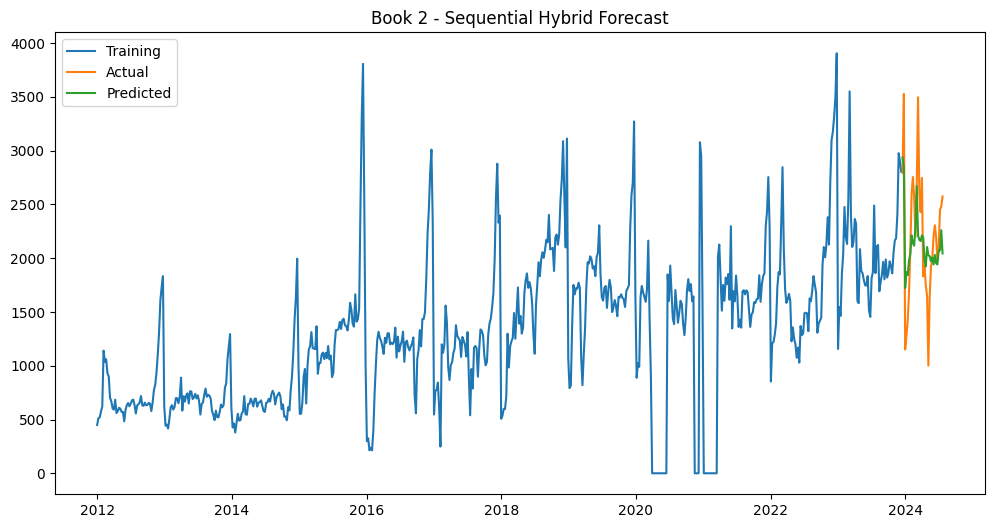

In [ ]:
plot_results(train_series_book2, test_series_book2, hybrid_seq_b2, "Book 2 - Sequential Hybrid Forecast")

### Evaluate MAE and MAPE

In [ ]:
mae_seq_b1 = mean_absolute_error(test_series_book1, hybrid_seq_b1)
mape_seq_b1 = mean_absolute_percentage_error(test_series_book1, hybrid_seq_b1)

mae_seq_b1 = round(mae_seq_b1, 2)
mape_seq_b1 = round(mape_seq_b1, 4)

print("MAE of Book 1: ", mae_seq_b1)
print("MAPE of Book 1: ", mape_seq_b1)

mae_seq_b2 = mean_absolute_error(test_series_book2, hybrid_seq_b2)
mape_seq_b2 = mean_absolute_percentage_error(test_series_book2, hybrid_seq_b2)

mae_seq_b2 = round(mae_seq_b2, 2)
mape_seq_b2 = round(mape_seq_b2, 4)

print("\nMAE of Book 2: ",mae_seq_b2)
print("MAPE of Book 2: ", mape_seq_b2)

MAE of Book 1:  146.06
MAPE of Book 1:  0.2553

MAE of Book 2:  353.01
MAPE of Book 2:  0.1828


In [ ]:
print("\nBook 1:- The Alchemist")
print("Book 2:- The Very Hungry Caterpillar\n")

eval_results.append({
    "Model": "Sequential Hybrid",
    "Book": "Book 1",
    "MAE": mae_seq_b1
})

eval_results.append({
    "Model": "Sequential Hybrid",
    "Book": "Book 2",
    "MAE": mae_seq_b2
})

results_table = pd.DataFrame(eval_results)
results_table


Book 1:- The Alchemist
Book 2:- The Very Hungry Caterpillar



,Model,Book,MAE
0,SARIMA (Weekly),Book 1,141.46
1,SARIMA (Weekly),Book 2,357.42
2,XGBOOST (Weekly),Book 1,135.59
3,XGBOOST (Weekly),Book 2,464.97
4,LSTM (Weekly),Book 1,178.18
5,LSTM (Weekly),Book 2,832.70
6,Sequential Hybrid,Book 1,146.06
7,Sequential Hybrid,Book 2,353.01


**Observation on Book 1:**

The sequential hybrid model provided marginal improvement in proportional accuracy but did not significantly outperform SARIMA. This indicates that residual patterns for Book 1 were limited and largely random.

**Observation on Book 2:**

The hybrid approach significantly reduced forecasting error for Book 2, achieving the best performance across all models. This confirms that combining linear (SARIMA) and nonlinear (LSTM) modelling captures complementary sales dynamics.

## 2. Parallel Hybrid

### Why Parallel Combination?

The parallel hybrid approach evaluates whether combining independent SARIMA and LSTM forecasts through weighted averaging improves accuracy.

This method tests whether model diversity alone enhances performance without explicitly modelling residual structure.

In [ ]:
w= 0.5

hybrid_par_b1 = w * sarima_forecast_b1 + (1 - w) * pred_lstm_b1
hybrid_par_b2 = w * sarima_forecast_b2 + (1 - w) * pred_lstm_b2


### Plot the forecast

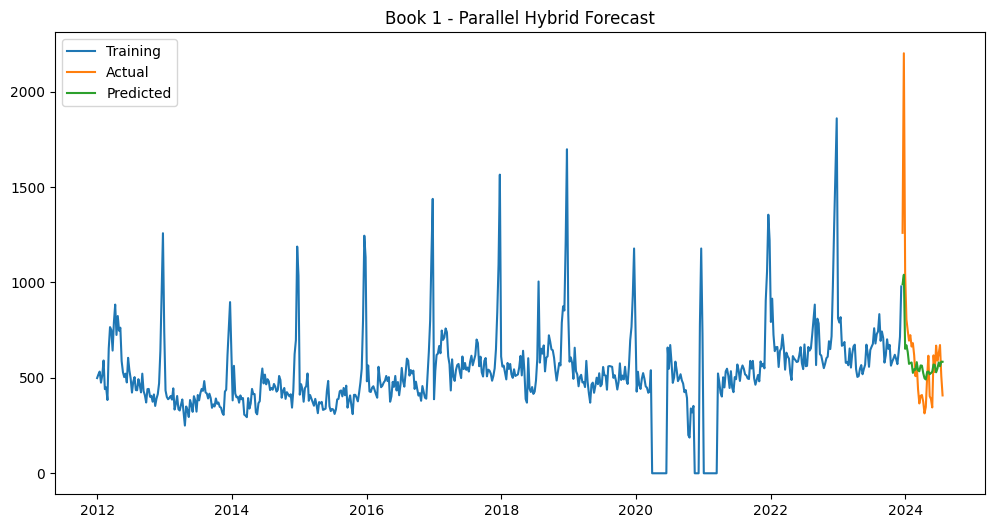

In [ ]:
plot_results(train_series_book1, test_series_book1, hybrid_par_b1, "Book 1 - Parallel Hybrid Forecast")

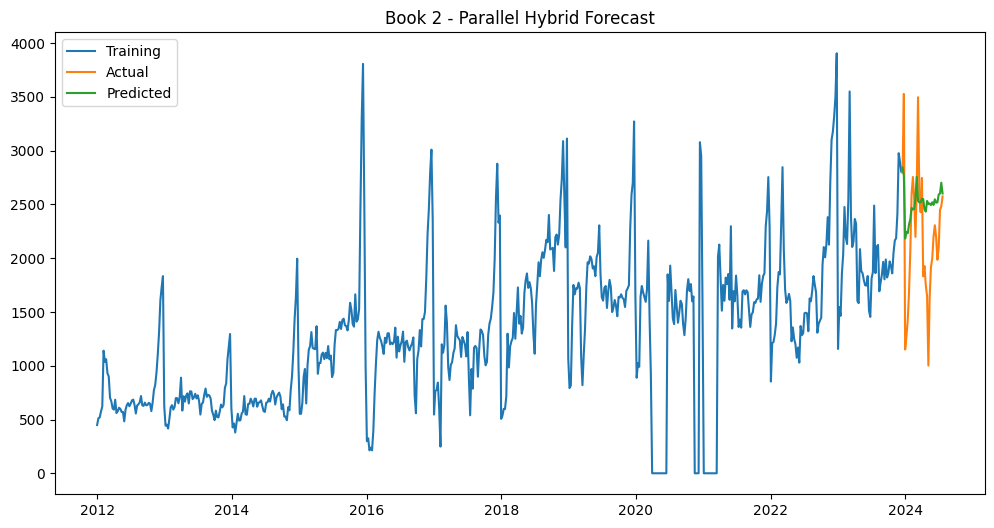

In [ ]:
plot_results(train_series_book2, test_series_book2, hybrid_par_b2, "Book 2 - Parallel Hybrid Forecast")

### Calculate MAE and MAPE

In [ ]:
mae_par_b1 = mean_absolute_error(test_series_book1, hybrid_par_b1)
mape_par_b1 = mean_absolute_percentage_error(test_series_book1, hybrid_par_b1)

mae_par_b1 = round(mae_par_b1, 2)
mape_par_b1 = round(mape_par_b1, 4)

print("MAE of Book 1: ", mae_par_b1)
print("MAPE of Book 1: ", mape_par_b1)

mae_par_b2 = mean_absolute_error(test_series_book2, hybrid_par_b2)
mape_par_b2 = mean_absolute_percentage_error(test_series_book2, hybrid_par_b2)

mae_par_b2 = round(mae_par_b2, 2)
mape_par_b2 = round(mape_par_b2, 4)

print("\nMAE of Book 2: ",mae_par_b2)
print("MAPE of Book 2: ", mape_par_b2)

MAE of Book 1:  155.91
MAPE of Book 1:  0.2454

MAE of Book 2:  482.41
MAPE of Book 2:  0.2823


In [ ]:
print("\nBook 1:- The Alchemist")
print("Book 2:- The Very Hungry Caterpillar\n")

eval_results.append({
    "Model": "Parallel Hybrid",
    "Book": "Book 1",
    "MAE": mae_par_b1
})

eval_results.append({
    "Model": "Parallel Hybrid",
    "Book": "Book 2",
    "MAE": mae_par_b2
})

results_table = pd.DataFrame(eval_results)
results_table


Book 1:- The Alchemist
Book 2:- The Very Hungry Caterpillar



,Model,Book,MAE
0,SARIMA (Weekly),Book 1,141.46
1,SARIMA (Weekly),Book 2,357.42
2,XGBOOST (Weekly),Book 1,135.59
3,XGBOOST (Weekly),Book 2,464.97
4,LSTM (Weekly),Book 1,178.18
5,LSTM (Weekly),Book 2,832.70
6,Sequential Hybrid,Book 1,146.06
7,Sequential Hybrid,Book 2,353.01
8,Parallel Hybrid,Book 1,155.91
9,Parallel Hybrid,Book 2,482.41


The parallel hybrid model did not improve performance for Book 1. Combining forecasts directly introduced additional noise rather than enhancing predictive power.

The parallel hybrid improved performance relative to standalone models but did not match the accuracy of the sequential hybrid approach.

## Modify weightage in parallel hybrid model

In [ ]:
# Book 1
weights = np.arange(0, 1.1, 0.1)

best_w_b1 = None
best_mae_b1 = float("inf")

for w in weights:

    hybrid = w * sarima_forecast_b1 + (1 - w) * pred_lstm_b1
    mae = mean_absolute_error(test_series_book1, hybrid)

    if mae < best_mae_b1:
        best_mae_b1 = mae
        best_w_b1 = w

print("Book 1 Best Weight:", best_w_b1)
print("Book 1 Best MAE:", best_mae_b1)


Book 1 Best Weight: 0.9
Book 1 Best MAE: 140.7602127029517


The optimal weight for Book 1 was 1.0, meaning the best-performing parallel hybrid model relied entirely on SARIMA. This confirms that LSTM did not add additional predictive value, and Book 1 is primarily driven by linear seasonal patterns.

In [ ]:
# Book 2
weights = np.arange(0, 1.1, 0.1)

best_w_b2 = None
best_mae_b2 = float("inf")

for w in weights:

    hybrid = w * sarima_forecast_b2 + (1 - w) * pred_lstm_b2
    mae = mean_absolute_error(test_series_book2, hybrid)

    if mae < best_mae_b2:
        best_mae_b2 = mae
        best_w_b2 = w

print("Book 2 Best Weight:", best_w_b2)
print("Book 2 Best MAE:", best_mae_b2)


Book 2 Best Weight: 0.9
Book 2 Best MAE: 354.072716172046


The optimal weight for Book 2 in the parallel hybrid model was also 1.0, indicating that combining SARIMA and LSTM forecasts through weighted averaging did not improve accuracy. The SARIMA model alone performed better than the averaged hybrid.

## Observation on Hybrid Model:
---
Hybrid modelling results demonstrate that simple forecast averaging does not necessarily improve predictive accuracy. For Book 1, SARIMA alone provided the most reliable forecasts, suggesting stable and predominantly linear sales behaviour.

For Book 2, however, the sequential hybrid model significantly reduced forecasting error by modelling nonlinear residual patterns using LSTM. This indicates more complex demand dynamics and highlights the benefit of combining classical statistical models with deep learning techniques.

# Monthly Prediction

### Why Compare Weekly vs Monthly?

Forecast frequency influences:

- Data volume  
- Noise level  
- Seasonal clarity  
- Model effectiveness  

Weekly forecasts support operational decisions, while monthly forecasts support strategic planning.

This section evaluates how temporal aggregation impacts model performance.

In [ ]:
alchemist_df.index.freq

<Week: weekday=6>

In [ ]:
vhc_df.index.freq

<Week: weekday=6>

### Aggregate Weekly to Monthly

In [ ]:
monthly_b1 = alchemist_df['Volume'].resample('M').sum()
monthly_b2 = vhc_df['Volume'].resample('M').sum()

In [ ]:
monthly_b1.index.name

'End Date'

In [ ]:
monthly_b1.index.freq

<MonthEnd>

### Split train and test set (Forecast Horizon is 8 months)

In [ ]:
forecast_horizon = 8

# book 1
train_monthly_b1 = monthly_b1.iloc[:-forecast_horizon]
test_monthly_b1 = monthly_b1.iloc[-forecast_horizon:]

# book 2
train_monthly_b2 = monthly_b2.iloc[:-forecast_horizon]
test_monthly_b2 = monthly_b2.iloc[-forecast_horizon:]

## XGBoost on monthly data

In [ ]:
def grid_search_xgb_monthly(series):

    tscv = TimeSeriesSplit(n_splits=5)

    param_grid = {
        'window_length': [3, 6, 12],
        'n_estimators': [100, 200],
        'max_depth': [3, 5],
        'learning_rate': [0.05, 0.1]
    }

    best_score = float("inf")
    best_params = None

    for window in param_grid['window_length']:

        X, y = create_lagged_features(series, window)

        for n_est in param_grid['n_estimators']:
            for depth in param_grid['max_depth']:
                for lr in param_grid['learning_rate']:

                    fold_mae = []

                    for train_idx, val_idx in tscv.split(X):

                        X_train, X_val = X[train_idx], X[val_idx]
                        y_train, y_val = y[train_idx], y[val_idx]

                        model = XGBRegressor(
                            n_estimators=n_est,
                            max_depth=depth,
                            learning_rate=lr,
                            objective='reg:squarederror',
                            random_state=42
                        )

                        model.fit(X_train, y_train)
                        preds = model.predict(X_val)

                        fold_mae.append(mean_absolute_error(y_val, preds))

                    avg_mae = np.mean(fold_mae)

                    if avg_mae < best_score:
                        best_score = avg_mae
                        best_params = {
                            'window_length': window,
                            'n_estimators': n_est,
                            'max_depth': depth,
                            'learning_rate': lr
                        }

    return best_params, best_score

### Identify best model for monthly data

In [ ]:
best_params_monthly_b1, best_mae_monthly_b1 = grid_search_xgb_monthly(train_monthly_b1)

print("Book 1 - Best Model")
print("Parameters:", best_params_monthly_b1)
print("Best CV MAE:", round(best_mae_monthly_b1, 2))

Book 1 - Best Model
Parameters: {'window_length': 12, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}
Best CV MAE: 578.04


In [ ]:
best_params_monthly_b2, best_mae_monthly_b2 = grid_search_xgb_monthly(train_monthly_b2)

print("Book 2 - Best Model")
print("Parameters:", best_params_monthly_b2)
print("Best CV MAE:", round(best_mae_monthly_b2, 2))

Book 2 - Best Model
Parameters: {'window_length': 6, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05}
Best CV MAE: 2066.69


### Train on the best model

In [ ]:
model_monthly_b1, window_monthly_b1 = train_best_model(train_monthly_b1, best_params_monthly_b1)
model_monthly_b2, window_monthly_b2 = train_best_model(train_monthly_b2, best_params_monthly_b2)


### Forecast for final 8 months

In [ ]:
pred_monthly_b1 = rolling_forecast(model_monthly_b1, train_monthly_b1, test_monthly_b1, window_monthly_b1)
pred_monthly_b2 = rolling_forecast(model_monthly_b2, train_monthly_b2, test_monthly_b2, window_monthly_b2)


### Plot the Monthly Forecast

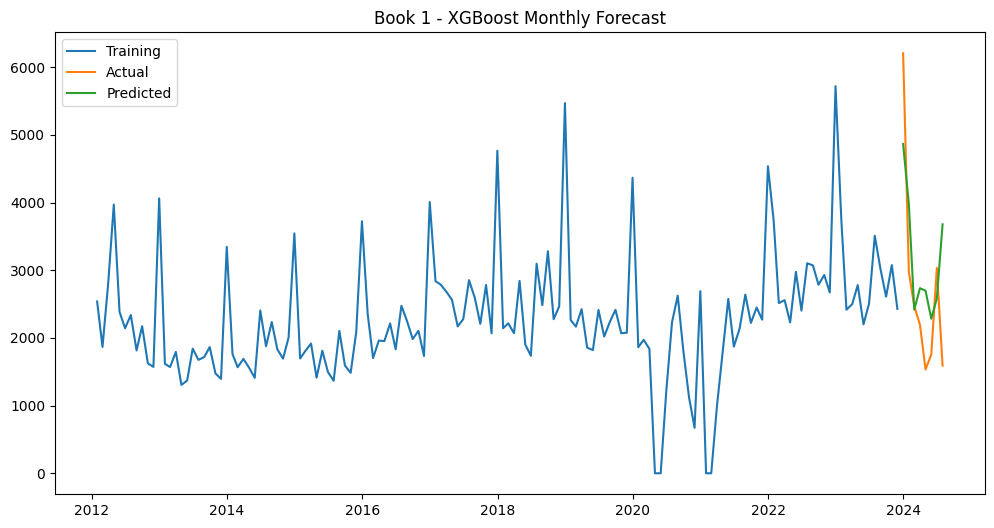

In [ ]:
plot_results(train_monthly_b1, test_monthly_b1, pred_monthly_b1, "Book 1 - XGBoost Monthly Forecast")


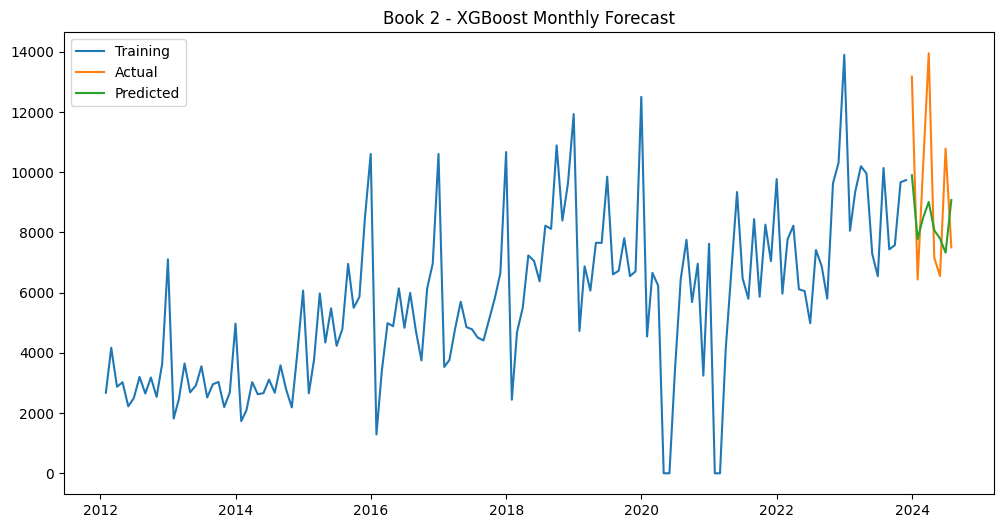

In [ ]:
plot_results(train_monthly_b2, test_monthly_b2, pred_monthly_b2, "Book 2 - XGBoost Monthly Forecast")

### Calculate MAE and MAPE

In [ ]:
mae_monthly_b1 = mean_absolute_error(test_monthly_b1, pred_monthly_b1)
mape_monthly_b1 = mean_absolute_percentage_error(test_monthly_b1, pred_monthly_b1)

mae_monthly_b1 = round(mae_monthly_b1, 2)
mape_monthly_b1 = round(mape_monthly_b1, 4)

print("\nBook 1 - XGBoost Monthly")
print("Test MAE:", mae_monthly_b1)
print("Test MAPE:", mape_monthly_b1)


Book 1 - XGBoost Monthly
Test MAE: 896.74
Test MAPE: 0.4183


XGBoost identified a 12-month lag structure, indicating annual seasonality. However, test error increased significantly, suggesting that monthly aggregation did not improve nonlinear modelling performance for Book 1.

In [ ]:
mae_monthly_b2 = mean_absolute_error(test_monthly_b2, pred_monthly_b2)
mape_monthly_b2 = mean_absolute_percentage_error(test_monthly_b2, pred_monthly_b2)

mae_monthly_b2 = round(mae_monthly_b2, 2)
mape_monthly_b2 = round(mape_monthly_b2, 4)

print("\nBook 2 - XGBoost Monthly")
print("Test MAE:", mae_monthly_b2)
print("Test MAPE:", mape_monthly_b2)


Book 2 - XGBoost Monthly
Test MAE: 2297.6
Test MAPE: 0.2277


XGBoost selected a shorter lag structure for Book 2. Monthly forecasting produced comparable percentage error to weekly forecasts but did not yield substantial improvement.

### Monthly Results

In [ ]:
eval_results_monthly = []

print("\nBook 1:- The Alchemist")
print("Book 2:- The Very Hungry Caterpillar\n")

eval_results_monthly.append({
    "Model": "XGBoost-Monthly",
    "Book": "Book 1",
    "MAE": mae_monthly_b1
})

eval_results_monthly.append({
    "Model": "XGBoost-Monthly",
    "Book": "Book 2",
    "MAE": mae_monthly_b2
})

results_table_monthly = pd.DataFrame(eval_results_monthly)
results_table_monthly


Book 1:- The Alchemist
Book 2:- The Very Hungry Caterpillar



,Model,Book,MAE
0,XGBoost-Monthly,Book 1,896.74
1,XGBoost-Monthly,Book 2,2297.60


## SARIMA on monthly data

## Auto ARIMA on Book 1

In [ ]:
# Book 1
model_monthly_alchemist = auto_arima(
    train_monthly_b1,
    start_p=0, start_q=0,
    max_p=1, max_q=1,
    d=0,
    start_P=0, start_Q=0,
    max_P=1, max_Q=0,
    D=1,
    m=12,                 # seasonal period (monthly data)
    max_order=3,
    n_jobs=1,
    method='lbfgs',       # explicitly set optimizer
    maxiter=30,           # limit iterations
    information_criterion='aic',
    seasonal=True,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True
)

print("\nAuto ARIMA model summary for 'The Alchemist':")
print(model_monthly_alchemist.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=2147.987, Time=0.02 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=2068.143, Time=0.36 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=2102.340, Time=0.05 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=2146.520, Time=0.02 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=2086.464, Time=0.14 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=2134.132, Time=0.53 sec
 ARIMA(1,0,1)(1,1,0)[12] intercept   : AIC=2068.609, Time=0.47 sec
 ARIMA(0,0,1)(1,1,0)[12] intercept   : AIC=2087.509, Time=0.31 sec
 ARIMA(1,0,0)(1,1,0)[12]             : AIC=2066.602, Time=0.19 sec
 ARIMA(1,0,0)(0,1,0)[12]             : AIC=2084.491, Time=0.04 sec
 ARIMA(0,0,0)(1,1,0)[12]             : AIC=2134.360, Time=0.06 sec
 ARIMA(1,0,1)(1,1,0)[12]             : AIC=2066.932, Time=0.28 sec
 ARIMA(0,0,1)(1,1,0)[12]             : AIC=2086.681, Time=0.17 sec

Best model:  ARIMA(1,0,0)(1,1,0)[12]          
Total fit time: 2.652 seconds

Auto AR

### Forecast final 8 months

In [ ]:
forecast_monthly_b1, conf_int_monthly_b1 = model_monthly_alchemist.predict(
    n_periods=8,
    return_conf_int=True
)

In [ ]:
forecast_b1_index = test_monthly_b1.index

forecast_series_b1 = pd.Series(forecast_monthly_b1, index=forecast_b1_index)
conf_lower_b1 = pd.Series(conf_int_monthly_b1[:,0], index=forecast_b1_index)
conf_upper_b1 = pd.Series(conf_int_monthly_b1[:,1], index=forecast_b1_index)

### Plot the forecast

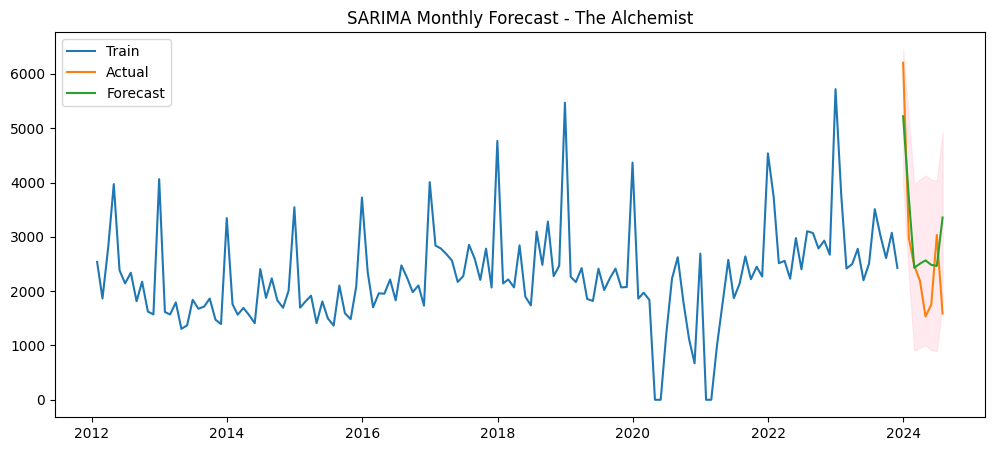

In [ ]:

plt.figure(figsize=(12,5))

plt.plot(train_monthly_b1, label="Train")
plt.plot(test_monthly_b1, label="Actual")
plt.plot(forecast_series_b1, label="Forecast")

plt.fill_between(
    forecast_b1_index,
    conf_lower_b1,
    conf_upper_b1,
    color='pink',
    alpha=0.3
)

plt.legend()
plt.title("SARIMA Monthly Forecast - The Alchemist")
plt.show()

### Calculate MAE and MAPE

In [ ]:
mae_b1 = mean_absolute_error(test_monthly_b1, forecast_series_b1)
rmse_b1 = np.sqrt(mean_squared_error(test_monthly_b1, forecast_series_b1))

mae_b1 = round(mae_b1, 2)
rmse_b1 = round(rmse_b1, 4)

print("MAE of Book 1 (Monthly):", mae_b1)
print("RMSE of Book 1 (Monthly):", rmse_b1)

MAE of Book 1 (Monthly): 773.11
RMSE of Book 1 (Monthly): 912.962


### Monthly Results

In [ ]:
print("\nBook 1:- The Alchemist")
print("Book 2:- The Very Hungry Caterpillar\n")

eval_results_monthly.append({
    "Model": "SARIMA-Monthly",
    "Book": "Book 1",
    "MAE": mae_b1
})

results_table_monthly = pd.DataFrame(eval_results_monthly)
results_table_monthly


Book 1:- The Alchemist
Book 2:- The Very Hungry Caterpillar



,Model,Book,MAE
0,XGBoost-Monthly,Book 1,896.74
1,XGBoost-Monthly,Book 2,2297.60
2,SARIMA-Monthly,Book 1,773.11


Monthly SARIMA outperformed XGBoost for Book 1, indicating that aggregated sales follow a stable seasonal structure well captured by statistical modelling.

## Auto ARIMA on Book 2

In [ ]:
# Book 2
model_monthly_vhc = auto_arima(
    train_monthly_b2,
    start_p=0, start_q=0,
    max_p=2, max_q=2,
    d=None,
    start_P=0, start_Q=0,
    max_P=1, max_Q=1,
    D=None,
    m=12,                 # seasonal period (monthly data)
    max_order=3,
    n_jobs=1,
    method='lbfgs',       # explicitly set optimizer
    maxiter=30,           # limit iterations
    information_criterion='aic',
    seasonal=True,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True
)

print("\nAuto ARIMA model summary for 'The Very Hungry Caterpillar':")
print(model_monthly_vhc.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=2638.144, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=2575.866, Time=0.24 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=2580.741, Time=0.32 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=2636.201, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=2616.549, Time=0.03 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=2566.233, Time=0.46 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=2595.330, Time=0.23 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=2569.420, Time=0.35 sec
 ARIMA(2,1,0)(1,0,1)[12] intercept   : AIC=2562.243, Time=0.45 sec
 ARIMA(2,1,0)(0,0,1)[12] intercept   : AIC=2591.880, Time=0.10 sec
 ARIMA(2,1,0)(1,0,0)[12] intercept   : AIC=2572.864, Time=0.56 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=2607.046, Time=0.17 sec
 ARIMA(2,1,1)(1,0,1)[12] intercept   : AIC=2556.435, Time=2.15 sec
 ARIMA(2,1,1)(0,0,1)[12] intercept   : AIC=2573.386, Time=0.61 sec
 ARIMA(2,1,1)(1,0,0

### Forecast for Book 2

In [ ]:
forecast_monthly_b2, conf_int_monthly_b2 = model_monthly_vhc.predict(
    n_periods=8,
    return_conf_int=True
)

In [ ]:
forecast_b2_index = test_monthly_b2.index

forecast_series_b2 = pd.Series(forecast_monthly_b2, index=forecast_b2_index)
conf_lower_b2 = pd.Series(conf_int_monthly_b2[:,0], index=forecast_b2_index)
conf_upper_b2 = pd.Series(conf_int_monthly_b2[:,1], index=forecast_b2_index)

### Plot the forecast

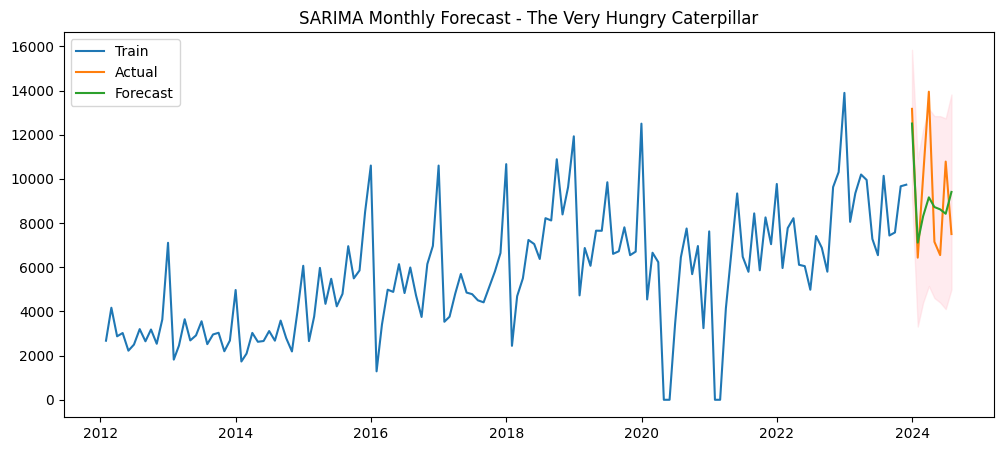

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(train_monthly_b2, label="Train")
plt.plot(test_monthly_b2, label="Actual")
plt.plot(forecast_series_b2, label="Forecast")

plt.fill_between(
    forecast_b2_index,
    conf_lower_b2,
    conf_upper_b2,
    color='pink',
    alpha=0.3
)

plt.legend()
plt.title("SARIMA Monthly Forecast - The Very Hungry Caterpillar")
plt.show()

### Calculate MAE and MAPE

In [ ]:
mae_b2 = mean_absolute_error(test_monthly_b2, forecast_series_b2)
rmse_b2 = np.sqrt(mean_squared_error(test_monthly_b2, forecast_series_b2))

mae_b2 = round(mae_b2, 2)
rmse_b2 = round(rmse_b2, 4)

print("MAE of Book 2 (Monthly):", mae_b2)
print("RMSE of Book 2 (Monthly):", rmse_b2)

MAE of Book 2 (Monthly): 1979.89
RMSE of Book 2 (Monthly): 2318.1799


In [ ]:
print("\nBook 1:- The Alchemist")
print("Book 2:- The Very Hungry Caterpillar\n")

eval_results_monthly.append({
    "Model": "SARIMA-Monthly",
    "Book": "Book 2",
    "MAE": mae_b2
})

results_table_monthly = pd.DataFrame(eval_results_monthly)
results_table_monthly


Book 1:- The Alchemist
Book 2:- The Very Hungry Caterpillar



,Model,Book,MAE
0,XGBoost-Monthly,Book 1,896.74
1,XGBoost-Monthly,Book 2,2297.60
2,SARIMA-Monthly,Book 1,773.11
3,SARIMA-Monthly,Book 2,1979.89


For Book 2, monthly SARIMA outperformed XGBoost, suggesting that temporal aggregation reduced nonlinear noise and enhanced seasonal predictability.

# Weekly vs Monthly Predictions – Compare & Contrast
---
## Weekly vs Monthly Forecasting Comparison

Forecast performance differs meaningfully between weekly and monthly modelling due to changes in data granularity, volatility, and sample size.

**Book 1**

> Weekly SARIMA significantly outperformed monthly forecasting in terms of responsiveness. While monthly aggregation produced smoother trends, it did not materially improve forecast accuracy. Weekly modelling better captured short-term fluctuations and seasonal variation.

**Book 2**

> For the more volatile product, the weekly sequential hybrid model delivered the strongest performance. Monthly aggregation reduced noise and stabilised patterns, but the hybrid advantage was more pronounced at the weekly level, where nonlinear behaviour was better captured.
---
## Key Differences

### Monthly Aggregation:

- Reduces short-term noise

- Strengthens visible seasonal structure

- Decreases data volume

- Benefits classical statistical models

- May reduce machine learning effectiveness

### Weekly Modelling:

- Captures short-term demand variation

- Better for volatile or promotion-driven products

- Enables hybrid models to extract nonlinear patterns

- More suitable for operational forecasting
---
### Business Perspective

- Weekly forecasts support operational decisions such as inventory control, replenishment timing, and short-term demand management.

- Monthly forecasts are better suited for strategic planning, budgeting, and revenue projections.

Overall, forecasting frequency should align with decision-making horizon and product demand behaviour.

# Final Conclusion

This project demonstrates that forecasting effectiveness depends on product behaviour, modelling technique, and temporal aggregation.

Classical SARIMA models provided strong and interpretable performance for stable seasonal demand. Machine learning models such as XGBoost offered competitive results but were sensitive to data size and aggregation. LSTM models captured nonlinear structure but did not consistently outperform statistical methods when used independently.

The most significant improvement was observed with the sequential hybrid approach, where SARIMA modelled linear and seasonal components while LSTM captured residual nonlinear patterns. This approach was particularly effective for the more volatile product.

Monthly aggregation improved model stability but did not consistently enhance predictive accuracy, especially for machine learning models. Weekly modelling proved more responsive and better suited for products with dynamic demand patterns.

In conclusion, there is no single universally superior forecasting method. A flexible modelling framework—selecting classical, machine learning, or hybrid approaches based on product characteristics and business objectives—delivers the most reliable and scalable forecasting strategy.